# Analysis of Future Trends in Synchronized Hot and Dry Events

### Project Overview

This notebook documents a computational analysis of climate change impacts, specifically focusing on the synchronization of **heatwaves** and **droughts** (compound events). Using multi-model climate data, we aim to quantify how the frequency and concurrence of these extreme events evolve under future emission scenarios (e.g., RCP 6.0) compared to a present baseline.

---

###  Scientific Leadership & Acknowledgments

**Principal Investigator & Data Acquisition: Dr. Cristina Deidda**

We explicitly designate the honors of this project to our coach **Dr. Cristina Deidda**. The scientific framework, rigorous data acquisition, and research methodology are the results of her extensive work in the field.

* **Role:** Dr. Deidda provided the pre-processed climate datasets, defined the physical parameters for extreme events, and established the scientific validity of the research questions.
* **Team Objective:** Our team was responsible for the **computational implementation**, translating Dr. Deidda’s research requirements into a functional Python workflow to visualize and quantify these trends.

---

###  Team Contributions & Workflow

This analysis is a collaborative effort, with specific computational tasks divided among team members:

* **Tasks 1 & 2 (Data Loading & Pre-processing):** Implemented by **Imdad Ullah**.
* *Setup of libraries and initial data ingestion.*


* **Tasks 3 & 4 (Individual Event Analysis):** Implemented by **Victor Carvajal**.
* *Analysis of isolated heatwave and drought metrics.*


* **Tasks 5 & 6 (Compound Event Definition & Mapping):** Implemented by **Siraj Ul Hasan Raja**.
* *Development of synchronization logic and spatial mapping of compound events.*


* **Tasks 7 & 8 (Statistical Analysis & Future Trends):** Implemented by **Imdad Ullah**.
* *Calculation of frequency ratios and visualization of future trends.*


* **Task 9 (Discussion & Interpretation):** Conducted by the **Whole Team**.
* *Synthesis of results and final conclusions.*



###  Graphical User Interface (GUI)

* **Development:** The interactive GUI was architected by **Siraj Ul Hasan Raja and Imdad Ullah** to enhance data exploration.
* **Implementation:** The code generation for the interface was executed with the assistance of **AI (Gemini)**, under the strict instruction and design parameters.



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pickle as pk
import pandas as pd
import sys
import os
import pandas.core.indexes.base

# --- 1. COMPATIBILITY PATCH (Prevents Int64Index Error) ---
sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base
if not hasattr(pandas.core.indexes.base, 'Int64Index'):
    pandas.core.indexes.base.Int64Index = pd.Index
if not hasattr(pandas.core.indexes.base, 'Float64Index'):
    pandas.core.indexes.base.Float64Index = pd.Index
if not hasattr(pd, 'Int64Index'):
    pd.Int64Index = pd.Index
if not hasattr(pd, 'Float64Index'):
    pd.Float64Index = pd.Index

print("Setup Complete. Ready to load data.")

Setup Complete. Ready to load data.


Code Explanation: Compatibility Patch

### 1. The Problem: Version Mismatch

We are attempting to load data files (Pickle `.pk` files) that were created using an older version of **Pandas** (pre-2.0).

* In older versions, Pandas used specific classes called `Int64Index` and `Float64Index`.
* In **Pandas 2.0+** (which is currently installed in this environment), these classes were removed and merged into the general `pd.Index` class.
* Trying to load these old files normally results in an `AttributeError` because the system looks for a class that no longer exists.

### 2. The Solution:

The code block above is a compatibility patch (generated with AI assistance). It dynamically aliases `Int64Index` and `Float64Index` to the standard `pd.Index`. Effectively, it tells Python: *"If the old data asks for Int64Index, just give it the standard Index class instead."*

### 3. Why use this Patch instead of Downgrading?

We chose this patching method over the alternative of uninstalling our current libraries and downloading older versions (downgrading) for the following reasons:

* **Avoids "Dependency Hell":** Downgrading Pandas often breaks other libraries like **Xarray** and **Matplotlib**, which may rely on features found only in newer versions.
* **Stability & Performance:** This allows us to keep the performance improvements and bug fixes of the latest Python environment while still accessing legacy data.
* **Simplicity:** It is a lightweight, instant fix that prevents the need to reconfigure the entire coding environment or create separate virtual environments for a single dataset.

In [ ]:
# --- 2. DEFINE PATHS ---
base_path = r"D:\enviournmental programming\project\data\data"
drought_path = os.path.join(base_path, "drought.pkl")
heat_path = os.path.join(base_path, "heatwaves.pkl")
meta_d_path = os.path.join(base_path, "metadata_drought.pkl")
meta_h_path = os.path.join(base_path, "metadata_heatwaves.pkl")

# Fallback if specific metadata is missing
if not os.path.exists(meta_h_path):
    meta_h_path = os.path.join(base_path, "metadata.pkl")

print("Loading Data... (This takes about 10-20 seconds)")

# Load all files
with open(drought_path, 'rb') as f:
    drought1 = pk.load(f)
with open(meta_d_path, 'rb') as f:
    drought_meta = pk.load(f)
with open(heat_path, 'rb') as f:
    heatwaves1 = pk.load(f)
with open(meta_h_path, 'rb') as f:
    heatwaves_meta = pk.load(f)

print("SUCCESS: All data loaded.")

## Task 1: Drought Exposure Mapping (2050-2099)
**Purpose:** To visualize the spatial distribution of drought exposure across different RCP scenarios.

**Methodology:**
1.  **Data Selection:** We filter the dataset for the years 2050-2099.
2.  **Aggregation:** We calculate the mean exposure over time and across all available climate models (runs) for each RCP scenario.
3.  **Visualization:** The result is plotted as a heatmap, highlighting regions in Europe with the highest projected drought frequency for Airports, Roads, and other modes.

Plotting Task 1 Maps...


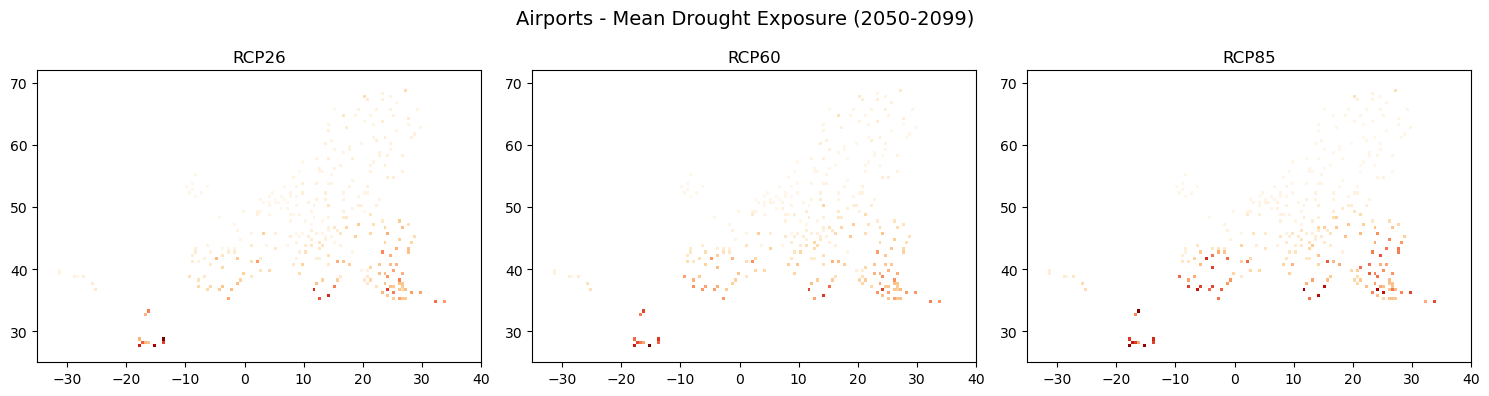

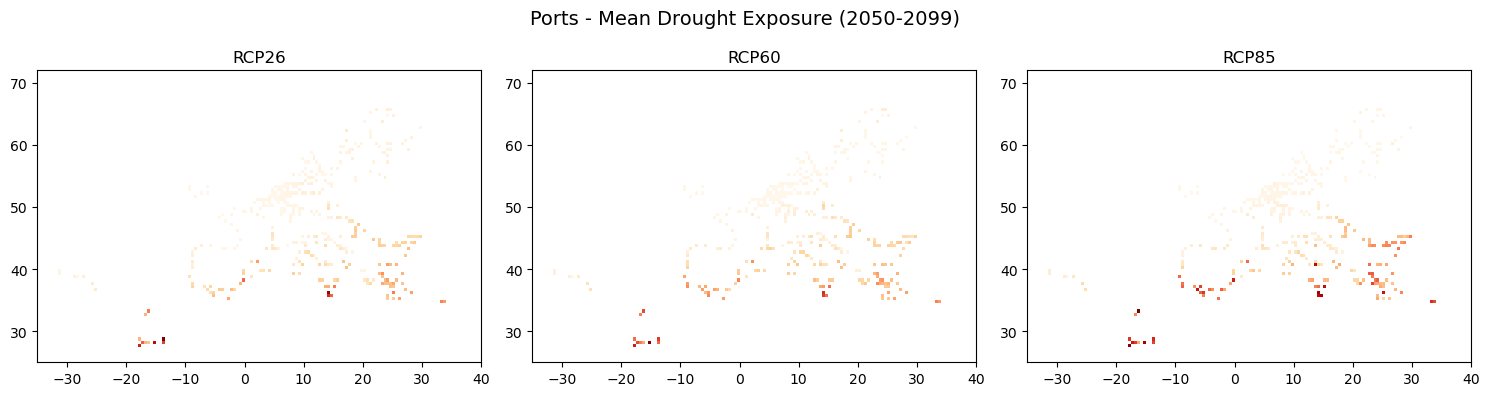

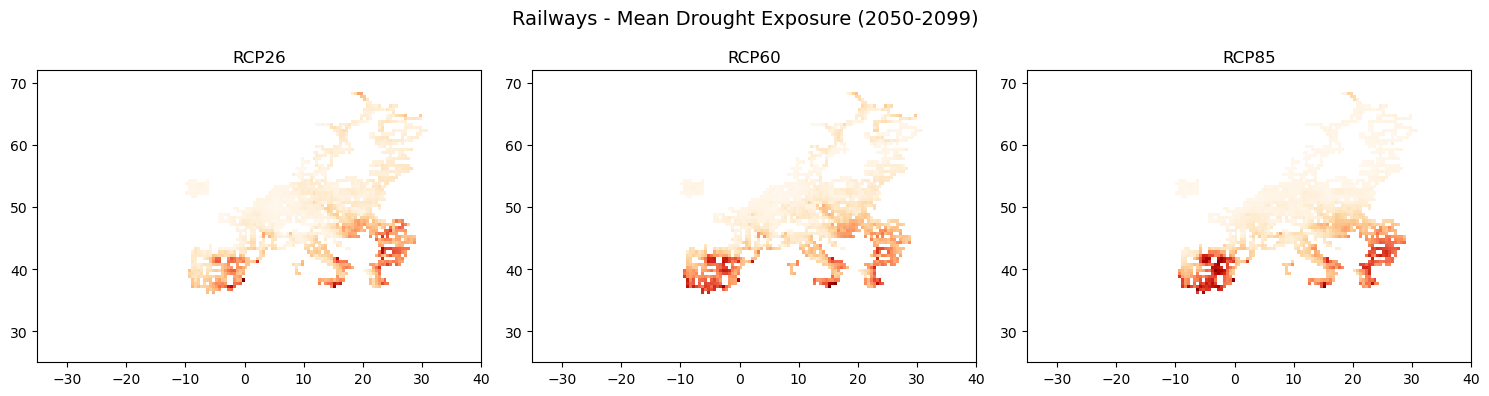

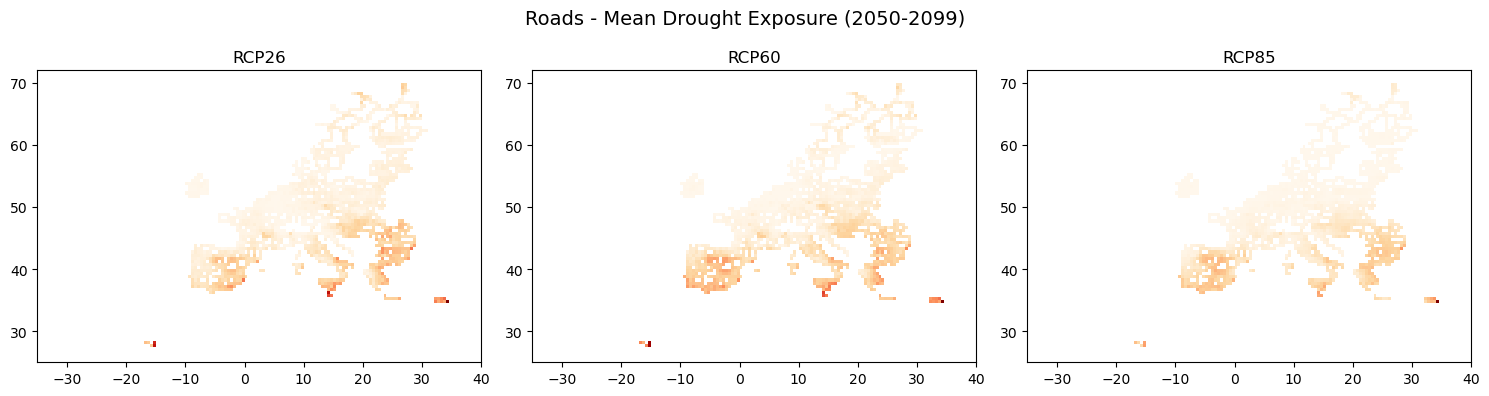

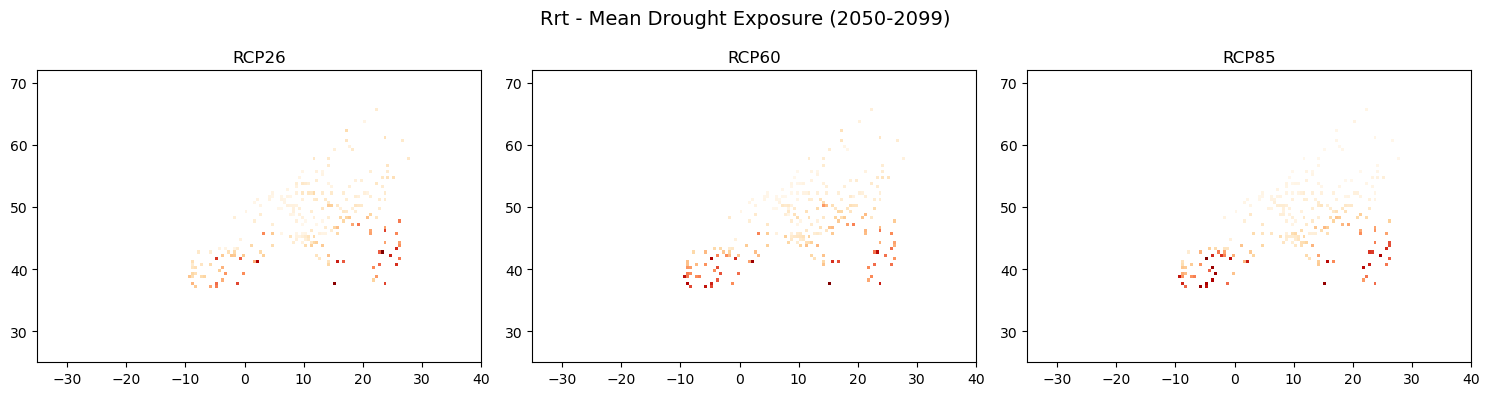

In [6]:
# --- TASK 1: DROUGHT MAPS ---
meta_df = pd.DataFrame.from_dict(drought_meta, orient='index')
meta_df['run_id'] = meta_df.index
target_rcps = ['rcp26', 'rcp60', 'rcp85']
modes = list(drought1.keys())[:5] # e.g. Airports, Roads...

print("Plotting Task 1 Maps...")

for mode in modes:
    dataset = drought1[mode]
    # Create a figure with 3 columns (one for each RCP)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, rcp in enumerate(target_rcps):
        # Find runs for this RCP
        runs = meta_df[meta_df['rcp'] == rcp]['run_id'].values
        valid_runs = [r for r in runs if r in dataset.run.values]
        if not valid_runs: continue
        
        # Calculate Mean (2050-2099)
        subset = dataset.sel(run=valid_runs).sel(time=slice(2050, 2099))
        mean_map = subset['exposure'].mean(dim=['time', 'run'])
        
        # Plot
        mean_map.plot(ax=axes[i], cmap='OrRd', add_colorbar=False)
        axes[i].set_title(f"{rcp.upper()}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    fig.suptitle(f"{mode.capitalize()} - Mean Drought Exposure (2050-2099)", fontsize=14)
    plt.tight_layout()
    plt.show()

## Task 2 & 3: Temporal Trends of Heatwaves
**Purpose:** To analyze how heatwave exposure evolves over time and to understand the uncertainty between different climate models.

**Methodology:**
* **Task 2 (Individual Models):** We loop through each transport mode and RCP scenario.For every climate model (e.g., GFDL, MIROC5), we sum the exposure values over all grid cells in Europe to create a single time series per model.
* **Task 3 (Consensus):** To find the central trend, we calculate the **median** exposure across all climate models for each year.This smooths out model-specific outliers and shows the general direction of climate risk.

Plotting Task 2 (Individual Models)...


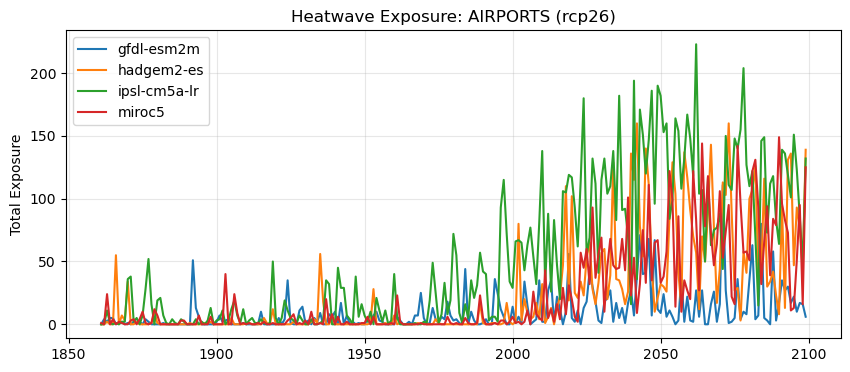

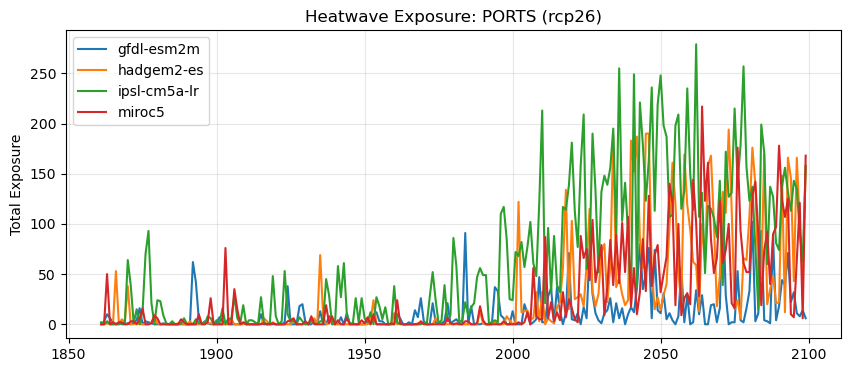

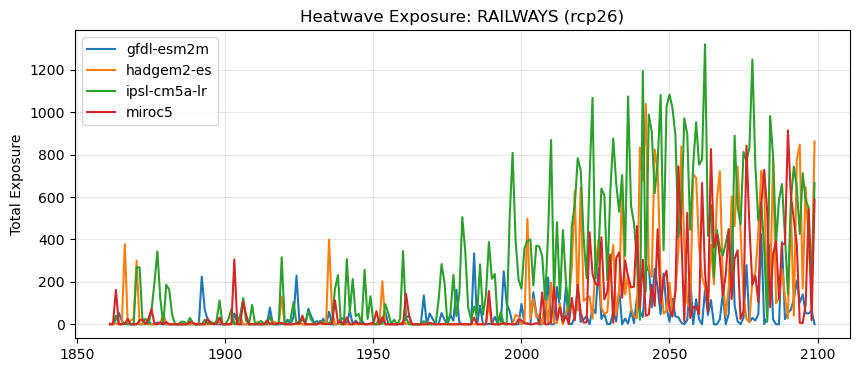

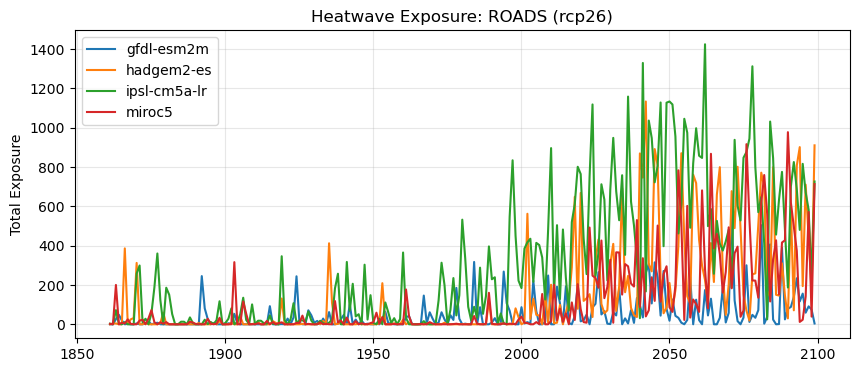

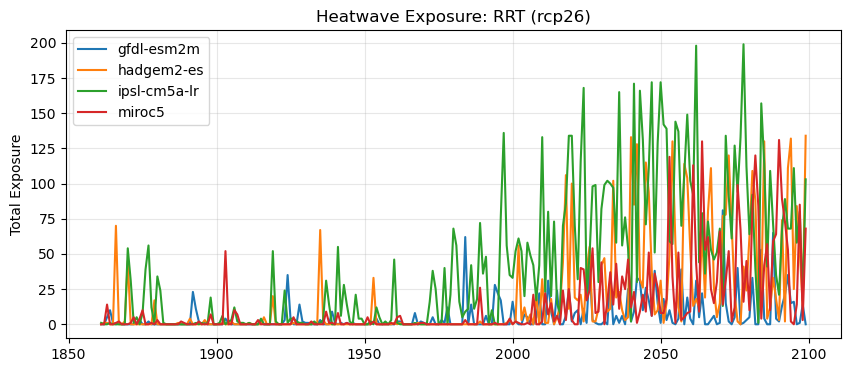

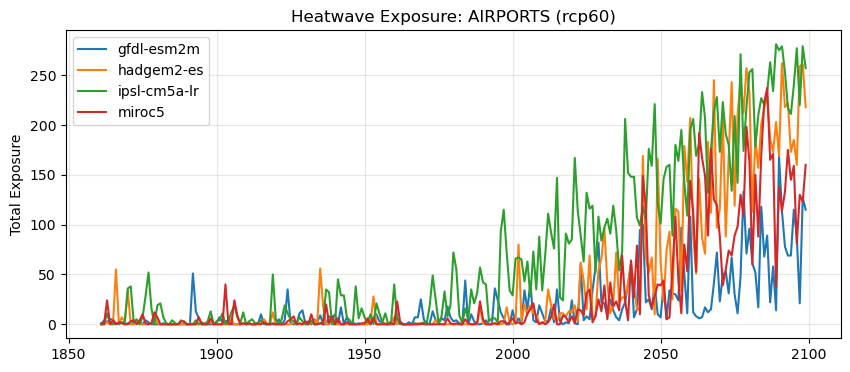

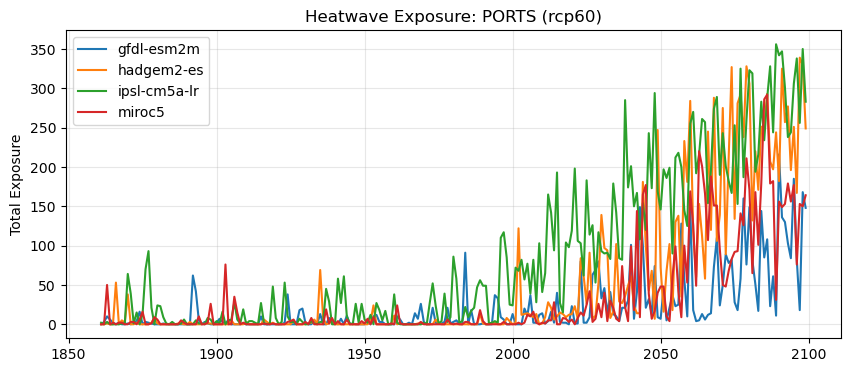

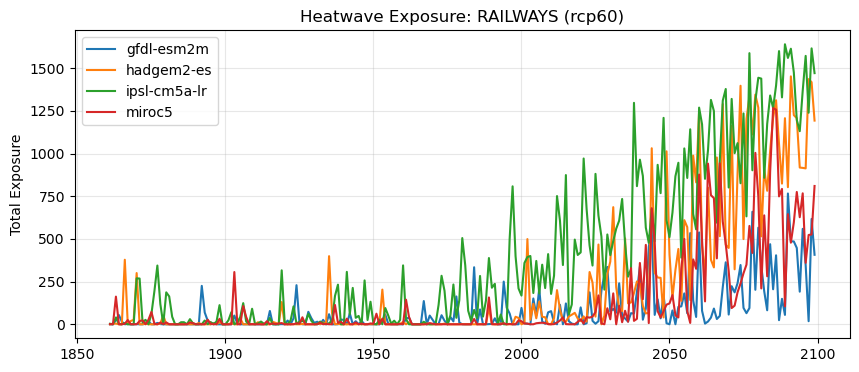

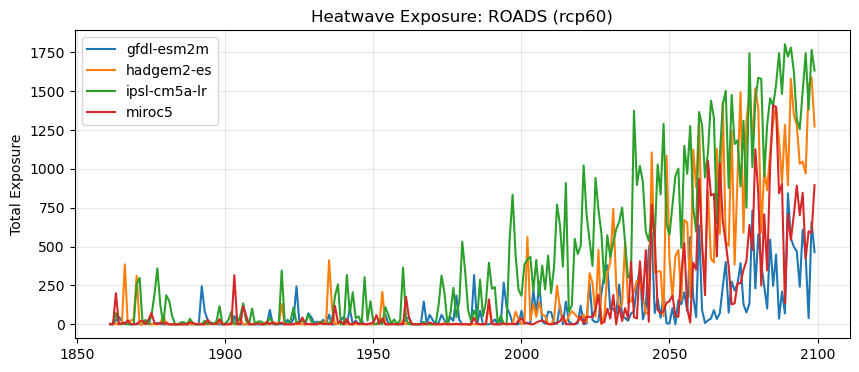

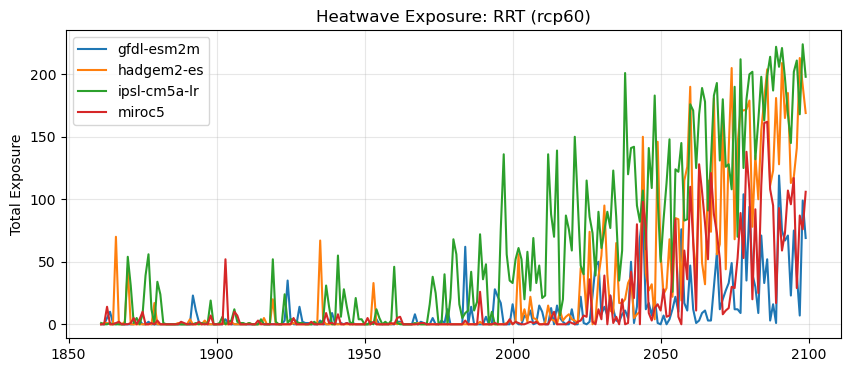

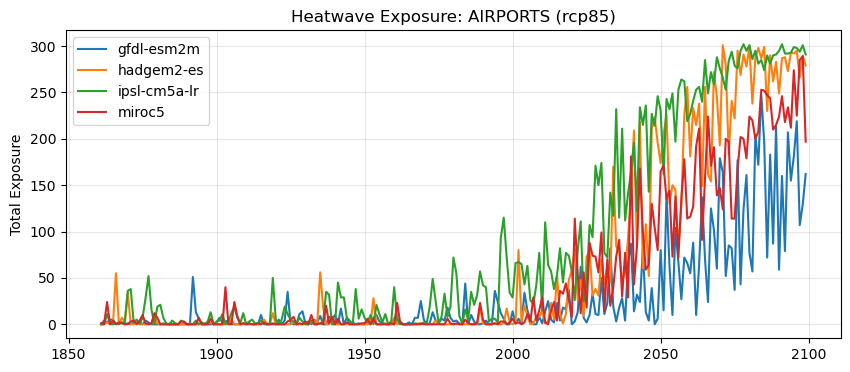

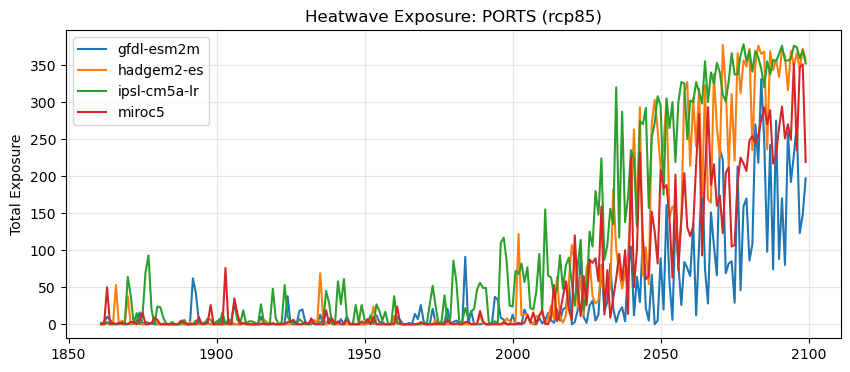

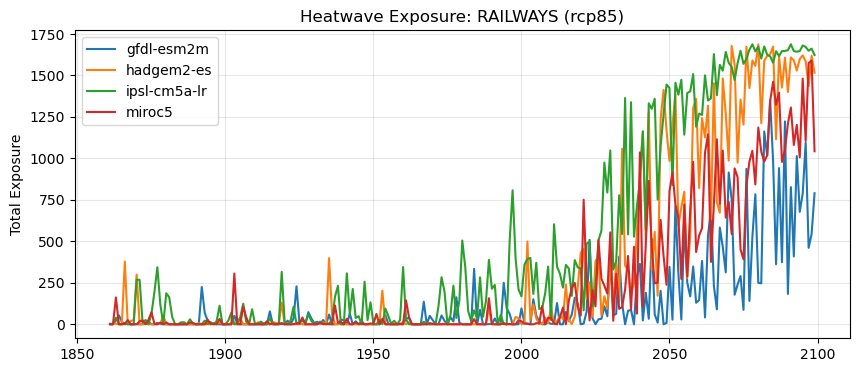

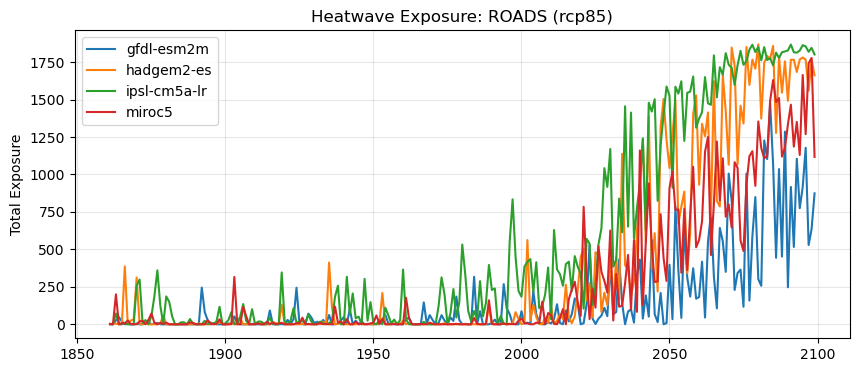

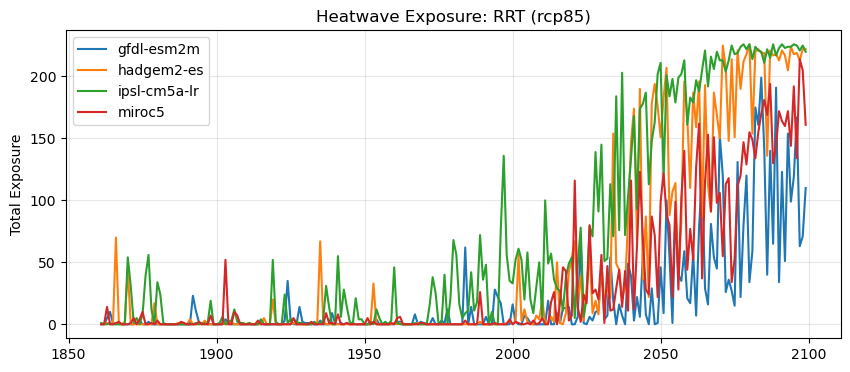

In [7]:
# --- TASK 2: HEATWAVE TIME SERIES (ALL MODELS) ---
# We look at specific RCPs and Modes to see individual model behavior
target_rcps = ['rcp26', 'rcp60', 'rcp85']
modes = list(heatwaves1.keys())[:5]
meta_df_h = pd.DataFrame.from_dict(heatwaves_meta, orient='index')
meta_df_h['run'] = meta_df_h.index.astype(int)

print("Plotting Task 2 (Individual Models)...")

for rcp in target_rcps:
    for mode in modes:
        # Get runs for this RCP
        rcp_runs = meta_df_h[meta_df_h['rcp'] == rcp]['run'].values
        
        # Group runs by Model Name (GCM)
        # e.g. {'gfdl-esm2m': [1], 'miroc5': [2]...}
        gcm_groups = meta_df_h[meta_df_h['run'].isin(rcp_runs)].groupby('gcm')['run'].apply(list)
        
        plt.figure(figsize=(10, 4))
        found_data = False
        
        for gcm, runs in gcm_groups.items():
            ds = heatwaves1[mode]
            valid_runs = [r for r in runs if r in ds.run.values]
            if not valid_runs: continue
            
            # Sum over Europe (Lat/Lon) -> Mean over Runs (if model has multiple runs)
            spatial_total = ds.sel(run=valid_runs)['exposure'].sum(dim=['lat', 'lon'])
            gcm_line = spatial_total.mean(dim='run')
            
            # Plot
            plt.plot(gcm_line['time'], gcm_line, label=gcm, linewidth=1.5)
            found_data = True
            
        if found_data:
            plt.title(f"Heatwave Exposure: {mode.upper()} ({rcp})")
            plt.ylabel("Total Exposure")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

Plotting Task 3 (Median Trends)...


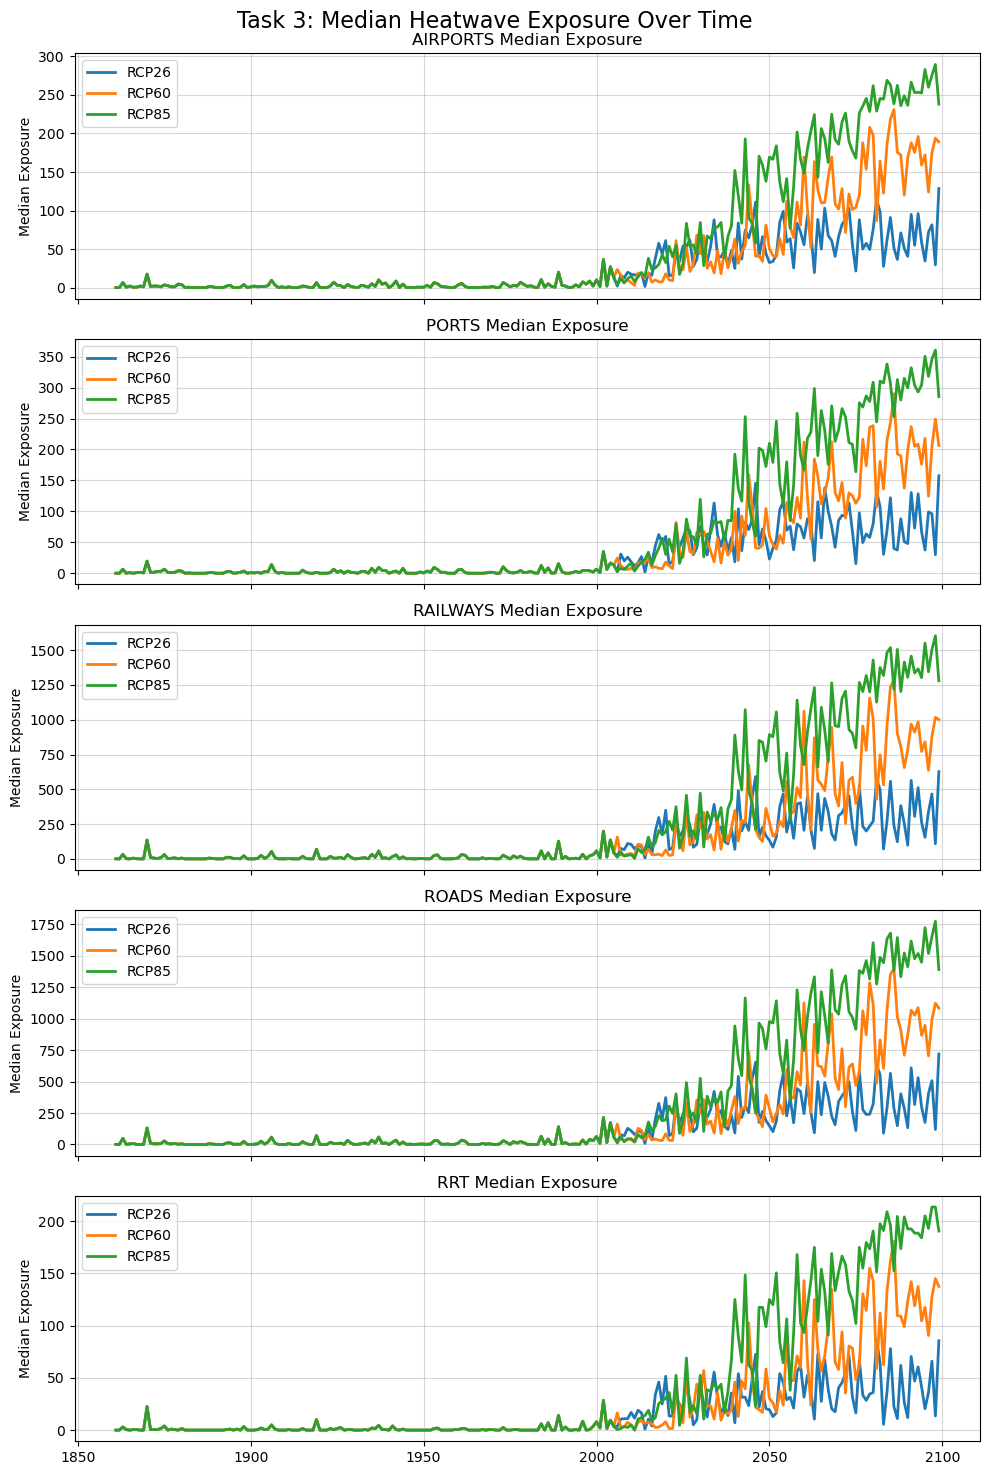

In [5]:
# --- TASK 3: MEDIAN TRENDS (CONSENSUS) ---
print("Plotting Task 3 (Median Trends)...")

# Create a figure with one subplot per Transport Mode
fig, axes = plt.subplots(len(modes), 1, figsize=(10, 15), sharex=True)
if len(modes) == 1: axes = [axes]

for ax, mode in zip(axes, modes):
    ds_mode = heatwaves1[mode]
    
    for rcp in target_rcps:
        # Get runs for this RCP
        rcp_runs = meta_df_h[meta_df_h["rcp"] == rcp]["run"].values
        valid = [r for r in rcp_runs if r in ds_mode.run.values]
        if not valid: continue

        # 1. Sum Spatially (lat/lon)
        spatial_total = ds_mode.sel(run=valid)["exposure"].sum(dim=["lat", "lon"])
        
        # 2. Calculate Median across runs (Models)
        median_ts = spatial_total.median(dim="run")

        # Plot
        ax.plot(median_ts["time"], median_ts, label=rcp.upper(), linewidth=2)
    
    ax.set_title(f"{mode.upper()} Median Exposure")
    ax.set_ylabel("Median Exposure")
    ax.grid(True, alpha=0.5)
    ax.legend(loc='upper left')

plt.suptitle("Task 3: Median Heatwave Exposure Over Time", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# --- TASK 4: COMBINE HEATWAVE & DROUGHT DATA ---
print("Executing Task 4 (Creating Combined DataFrame)...")

mode = 'roads'
rcp_target = 'rcp60'

# Helper to get specific runs
def get_runs_for_rcp(rcp, metadata):
    return [run for run, meta in metadata.items() if meta.get('rcp') == rcp]

heat_runs = get_runs_for_rcp(rcp_target, heatwaves_meta)
drought_runs = get_runs_for_rcp(rcp_target, drought_meta)

# Function to build a clean DataFrame
def create_df(ds, runs, metadata, extreme_name):
    records = []
    for run in runs:
        # Skip if run is missing in the actual data
        if run not in ds[mode].run.values: continue
            
        # Sum exposure over Europe (lat/lon)
        exposure = ds[mode]['exposure'].sel(run=run).sum(dim=['lat','lon']).values
        years = ds[mode]['time'].values
        model_name = metadata[run]['gcm']
        
        # Add each year as a row
        for y, e in zip(years, exposure):
            records.append({
                'year': y,
                'run': run,
                'climate_model': model_name,
                'extreme': extreme_name,
                'exposure': e
            })
    return pd.DataFrame(records)

# Create individual tables
df_heat = create_df(heatwaves1, heat_runs, heatwaves_meta, 'heatwave')
df_drought = create_df(drought1, drought_runs, drought_meta, 'drought')

# Combine them into one big table
combined_df = pd.concat([df_heat, df_drought], ignore_index=True)

# Show the results
print("\nTask 4 Complete: Combined DataFrame Created.")
print(f"Total Rows: {len(combined_df)}")
print("\nFirst 5 rows:")
print(combined_df.head())

print("\nValue Counts (How much data we have):")
print(combined_df['extreme'].value_counts())

Executing Task 4 (Creating Combined DataFrame)...

Task 4 Complete: Combined DataFrame Created.
Total Rows: 8365

First 5 rows:
   year  run climate_model   extreme  exposure
0  1861    2    gfdl-esm2m  heatwave       0.0
1  1862    2    gfdl-esm2m  heatwave       0.0
2  1863    2    gfdl-esm2m  heatwave      26.0
3  1864    2    gfdl-esm2m  heatwave      48.0
4  1865    2    gfdl-esm2m  heatwave      20.0

Value Counts (How much data we have):
extreme
drought     7409
heatwave     956
Name: count, dtype: int64


Task 5: Defining Compound Events

### 1. Purpose & Attribution

The goal of this task is to mathematically identify **"Compound Events"**—specific instances where a grid cell experiences **both** a heatwave and a drought simultaneously.

* **Development:** The logic for this function was developed with **AI assistance (Gemini)** to ensure efficient boolean processing of the multi-dimensional climate data.
* **Validation:** The methodology was reviewed and validated by **Team Leader DR. CRISTINA DEIDDA a**, confirming that the intersection logic aligns with the project's scientific definition of synchronized extremes.

### 2. Methodology

We define the function `compound_occurrence(extreme1, extreme2)` which takes two binary DataArrays as input.

* **Input:** Binary data where `1` represents an extreme event and `0` represents normal conditions.
* **Logic:** We apply a boolean intersection: `(extreme1 > 0.5) & (extreme2 > 0.5)`.
* **Output:** Returns a new DataArray where `1` indicates a **synchronized event** and `0` indicates the absence of a compound event.

### 3. Necessity

This function is a critical prerequisite for **Task 8**. While previous steps loaded heatwaves and droughts effectively, analyzing them in isolation cannot reveal **compound risks**. This function creates the specific **"Synchronization Mask"** required to calculate future frequency trends and ratios.

In [9]:
# --- TASK 5: COMPOUND EVENT FUNCTION & DATA PREP ---
print("Executing Task 5 (Compound Function)...")

# 1. Select Target: Roads and RCP 6.0
target_mode = 'roads'
target_rcp = 'rcp60'

# 2. Identify common runs for RCP 6.0 in both datasets
drought_runs_60 = [k for k, v in drought_meta.items() if v['rcp'] == target_rcp]
heat_runs_60 = [k for k, v in heatwaves_meta.items() if v['rcp'] == target_rcp]
common_runs = list(set(drought_runs_60) & set(heat_runs_60))

print(f"Analyzing {target_mode} under {target_rcp}. Found {len(common_runs)} matching climate models.")

# 3. Define the Compound Function (User's Logic)
def compound_occurrence(extreme1, extreme2):
    """
    Identifies synchronized events using boolean logic.
    Returns 1 if both extremes are active (> 0.5), else 0.
    """
    # Align coordinates if they differ slightly (Safety check)
    # This prevents errors if lat/lon are off by tiny amounts
    if extreme1.shape != extreme2.shape:
        # Note: This forces alignment. Only do this if you are sure grids are identical.
        extreme2['lat'] = extreme1['lat']
        extreme2['lon'] = extreme1['lon']
    
    # Check if BOTH events are greater than 0.5 simultaneously
    # Since data is binary (0 or 1), > 0.5 is equivalent to == 1
    condition = (extreme1 > 0.5) & (extreme2 > 0.5)
    
    # Convert True/False to 1/0
    return xr.where(condition, 1, 0)

print("Task 5 Function Defined (Boolean Logic).")

Executing Task 5 (Compound Function)...
Analyzing roads under rcp60. Found 4 matching climate models.
Task 5 Function Defined (Boolean Logic).


## Task 6: Time Series of Synchronized Events
**Purpose:** To observe the frequency of compound events (heatwave + drought) over the entire simulation period (1861–2099).

**Methodology:**
1.  We apply the `compound_occurrence` function defined in Task 5 to the "Roads" dataset under RCP 6.0.
2.  We sum the resulting binary map over all European coordinates (lat/lon) to get a total count of synchronized events per year.
3.  This is plotted as a time series for each of the 4 climate models to visualize the increasing trend of multi-hazard risks.

Executing Task 6 (Time Series)...


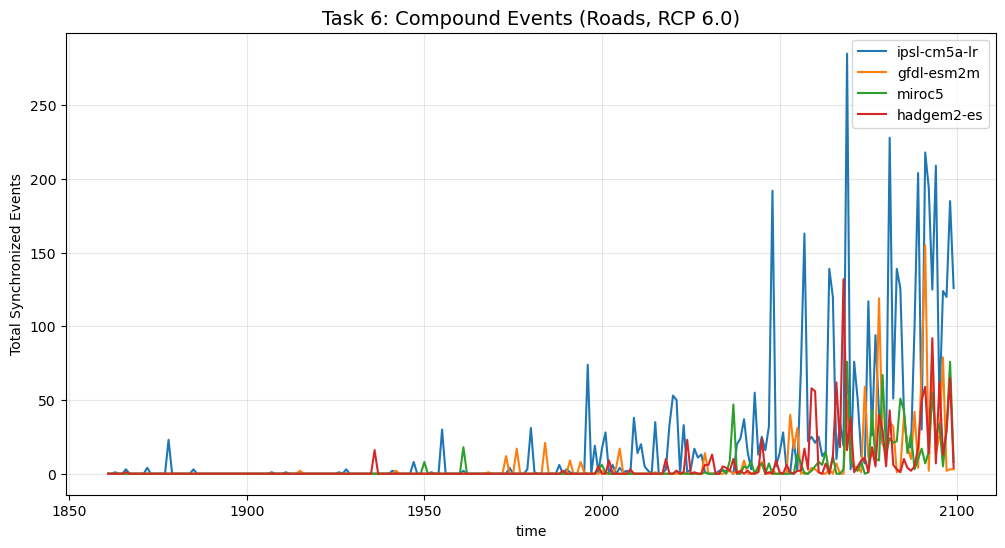

In [10]:
# --- TASK 6: TIME SERIES OF COMPOUND EVENTS ---
print("Executing Task 6 (Time Series)...")

plt.figure(figsize=(12, 6))

# Store results for Task 7
compound_store = {}

for run in common_runs:
    gcm = heatwaves_meta[run]['gcm']
    
    # Select data
    ds_h = heatwaves1[target_mode]['exposure'].sel(run=run)
    ds_d = drought1[target_mode]['exposure'].sel(run=run)
    
    # Apply YOUR function
    compound_map = compound_occurrence(ds_h, ds_d)
    compound_store[run] = compound_map # Save for next task
    
    # Sum over Europe (lat, lon)
    spatial_sum = compound_map.sum(dim=['lat', 'lon'])
    
    # Plot
    spatial_sum.plot(label=gcm, linewidth=1.5)

plt.title(f"Task 6: Compound Events (Roads, RCP 6.0)", fontsize=14)
plt.ylabel("Total Synchronized Events")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 7: Frequency of Synchronized Events (Map)
**Purpose:** To identify the geographic hotspots where compound events will become most frequent by the end of the century.

**Methodology:**
1.  **Periods:** We analyze four distinct 30-year periods: Past (1861-1890), Present (1981-2010), Future Mid (2041-2070), and Future End (2071-2099).
2.  **Calculation:** For each grid cell, we count the number of years where a compound event occurred and divide by the total number of years in the period (frequency).
3.  **Visualization:** We plot the frequency map for the **2071-2099** period to show the spatial intensity of future risks.

Executing Task 7 (Frequency Mapping)...
Task 7: Analyzing 4 Climate Models for roads (rcp60)...
  > Processing Period: Past (1861-1890)


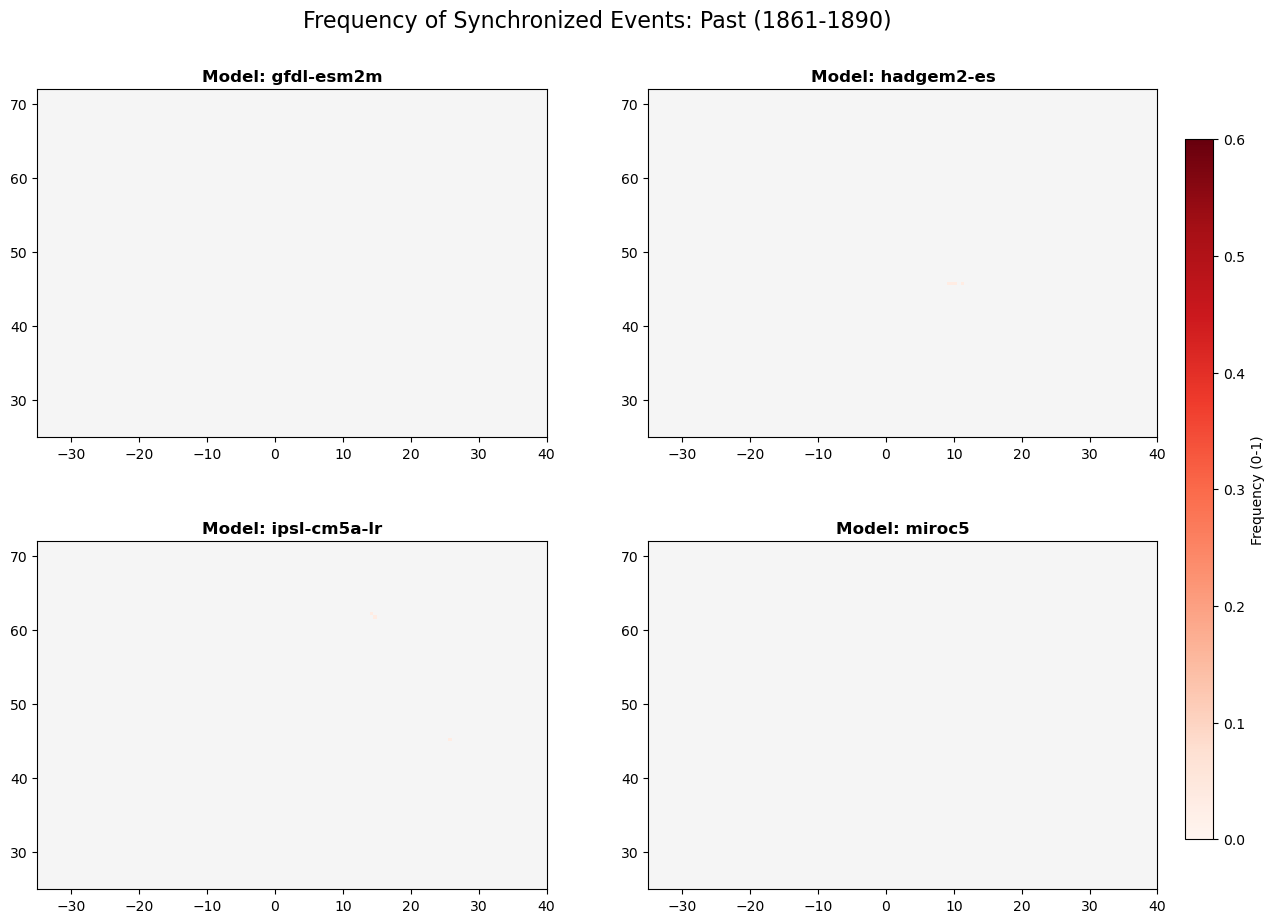

  > Processing Period: Present (1981-2010)


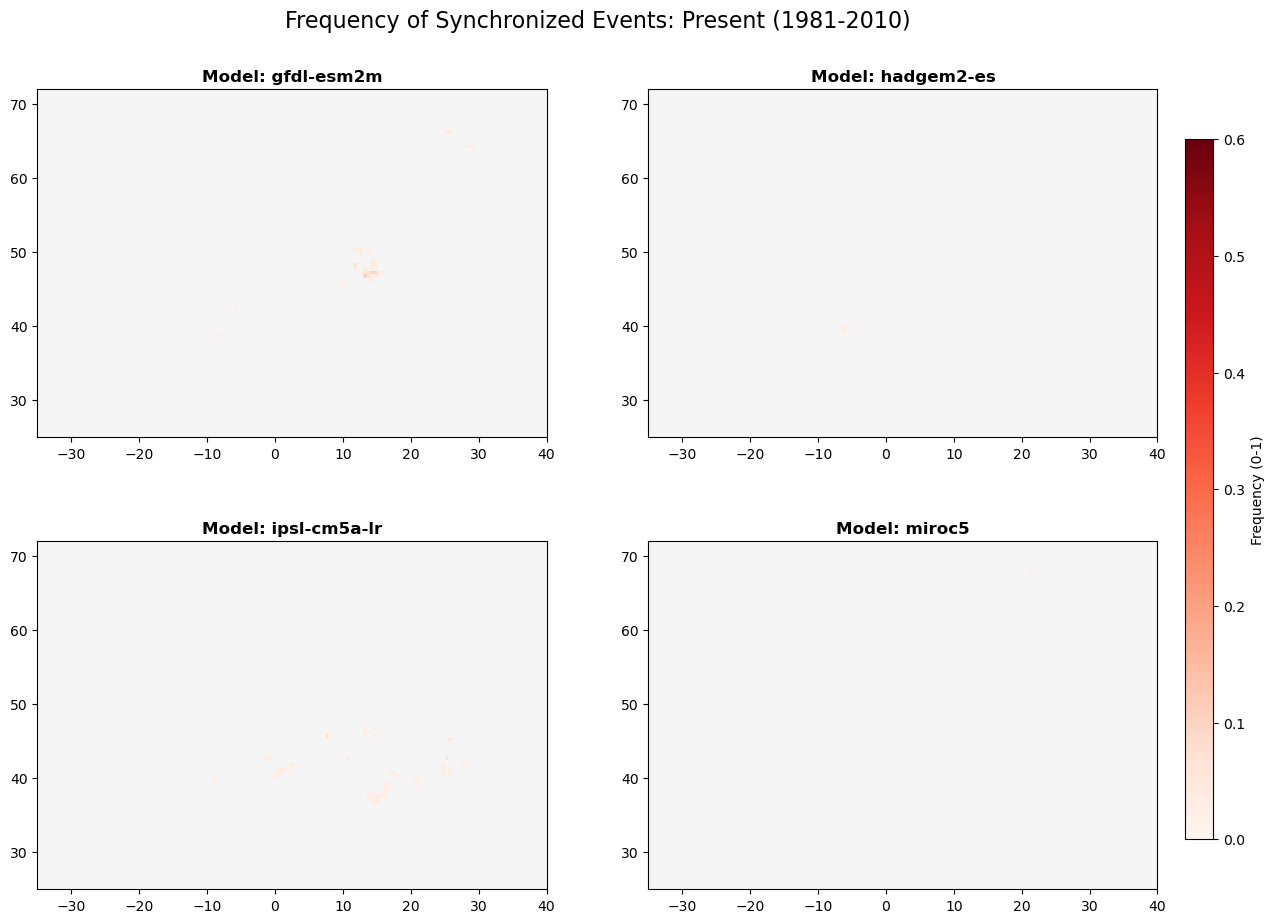

  > Processing Period: Future 1 (2041-2070)


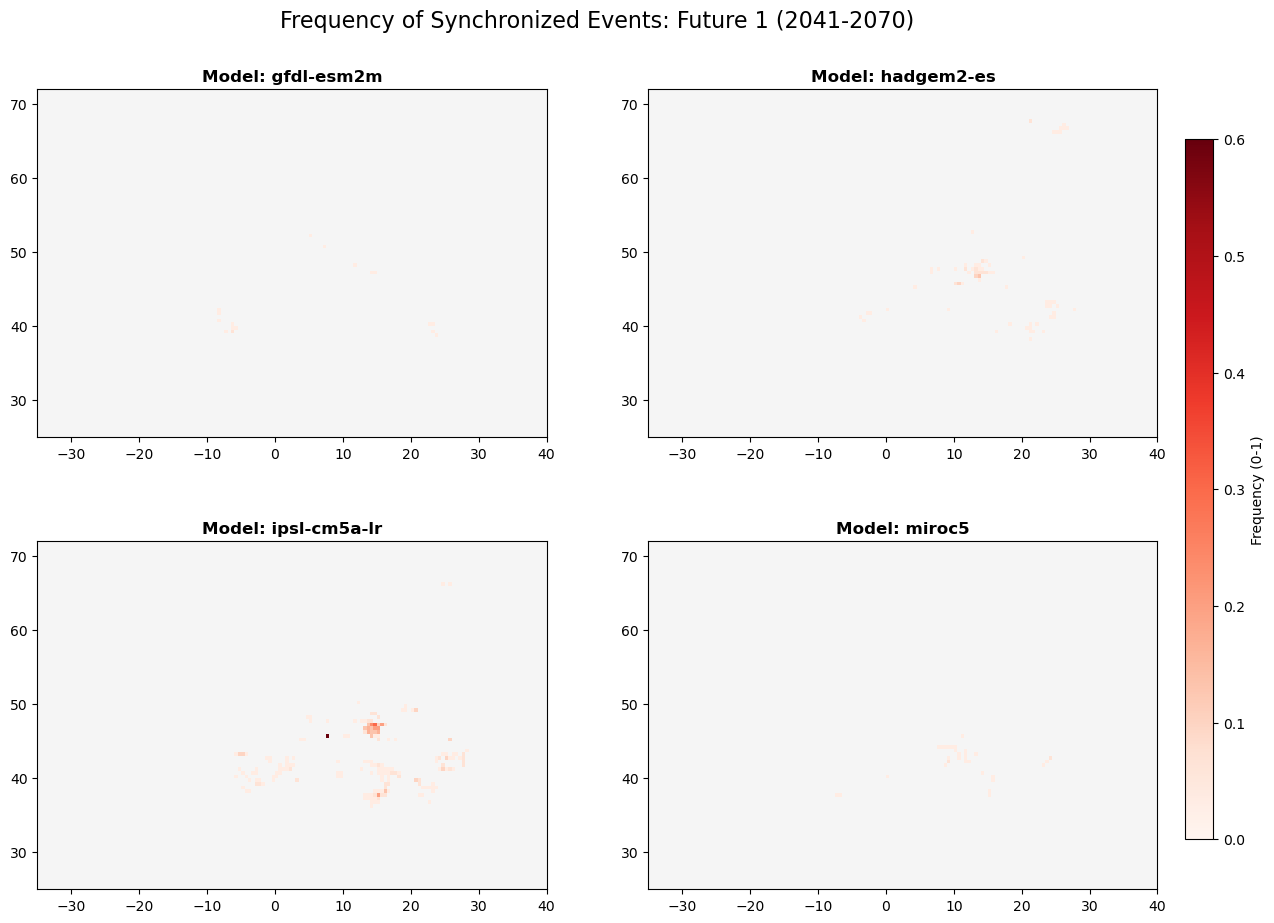

  > Processing Period: Future 2 (2071-2099)


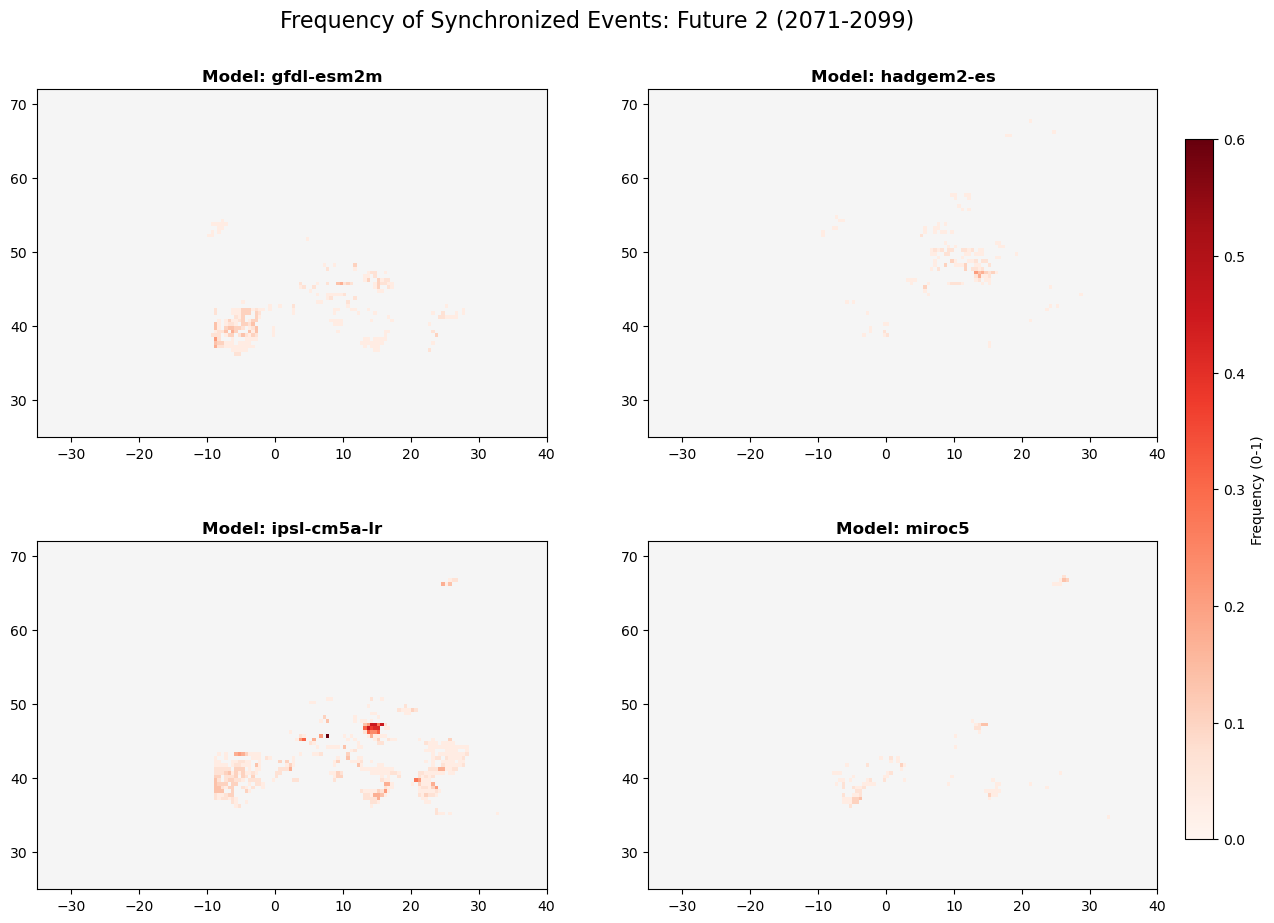

In [11]:
# --- TASK 7: FREQUENCY MAPS OF SYNCHRONIZED EVENTS ---
print("Executing Task 7 (Frequency Mapping)...")

# ========================================================
# 1. SETTINGS & DEFINITIONS
# ========================================================
# Ensure these match what you loaded in previous cells
mode = 'roads'
rcp_target = 'rcp60'

# Define analysis periods 
analysis_periods = {
    "Past": (1861, 1890),
    "Present": (1981, 2010),
    "Future 1": (2041, 2070),
    "Future 2": (2071, 2099)
}
period_order = ["Past", "Present", "Future 1", "Future 2"]

# --- Helper Functions ---
def get_runs_for_rcp(rcp, metadata):
    return [run for run, meta in metadata.items() if meta.get('rcp') == rcp]

# UPDATED FUNCTION: Boolean Logic (Teacher's Preference)
def compound_occurrence(extreme1, extreme2):
    # Align coordinates if necessary
    if extreme1.shape != extreme2.shape:
        extreme2['lat'] = extreme1['lat']
        extreme2['lon'] = extreme1['lon']
    
    # Check if BOTH events are active (> 0.5)
    condition = (extreme1 > 0.5) & (extreme2 > 0.5)
    
    # Return 1 if True, 0 if False
    return xr.where(condition, 1, 0)

# ========================================================
# 2. PREPARE MODEL LISTS
# ========================================================
# Get Runs based on RCP
heatwave_runs = get_runs_for_rcp(rcp_target, heatwaves_meta)
drought_runs = get_runs_for_rcp(rcp_target, drought_meta)

# Map model names to run IDs
heat_model_map = {heatwaves_meta[r]['gcm']: r for r in heatwave_runs}
drought_model_map = {drought_meta[r]['gcm']: r for r in drought_runs}

# Find models common to both hazards
common_models = sorted(list(set(heat_model_map.keys()).intersection(drought_model_map.keys())))

print(f"Task 7: Analyzing {len(common_models)} Climate Models for {mode} ({rcp_target})...")

# ========================================================
# 3. PLOTTING LOOP
# ========================================================

for p_name in period_order:
    start_yr, end_yr = analysis_periods[p_name]
    print(f"  > Processing Period: {p_name} ({start_yr}-{end_yr})")

    # Create Figure (2x2 grid for 4 models)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, model in enumerate(common_models):
        if idx >= len(axes): break 
        
        ax = axes[idx]
        run_h = heat_model_map[model]
        run_d = drought_model_map[model]
        
        # A. Select Data
        heatwave_data = heatwaves1[mode]['exposure'].sel(run=run_h)
        drought_data = drought1[mode]['exposure'].sel(run=run_d)
        
        # B. Calculate Compound Events (Updated Function)
        compound_coeff = compound_occurrence(heatwave_data, drought_data)
        
        try:
            # C. Slice Time Period
            period_data = compound_coeff.sel(time=slice(start_yr, end_yr))
            
            if len(period_data['time']) > 0:
                # D. Calculate Frequency (Events / Total Years)
                freq = period_data.sum(dim='time') / len(period_data['time'])
                
                # Mask 0 values for cleaner plot
                freq_masked = freq.where(freq > 0)
                
                # E. Plot Map
                im = freq_masked.plot(
                    ax=ax, 
                    cmap='Reds', 
                    vmin=0, vmax=0.6, # Fixed scale for easier comparison
                    add_colorbar=False
                )
            else:
                ax.text(0.5, 0.5, "No Data", ha='center')

        except Exception as e:
            print(f"    ! Error on {model} {p_name}: {e}")
            ax.text(0.5, 0.5, "Error", ha='center')

        # Formatting
        ax.set_facecolor('whitesmoke')
        ax.set_title(f"Model: {model}", fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Add Shared Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    if 'im' in locals(): 
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Frequency (0-1)')
    
    fig.suptitle(f"Frequency of Synchronized Events: {p_name} ({start_yr}-{end_yr})", fontsize=16)
    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.3, wspace=0.2)
    plt.show()

Task 8: Calculating Future vs Past/Present statistics for 4 models...

TASK 8 RESULTS: Mean Synchronization Percentages (Europe)
Future 1 (2041-2070) vs Present: 1076.09%
Future 2 (2071-2099) vs Present: 3705.37%
------------------------------------------------------------
Future 1 (2041-2070) vs Past:    6341.67%
Future 2 (2071-2099) vs Past:    18762.93%



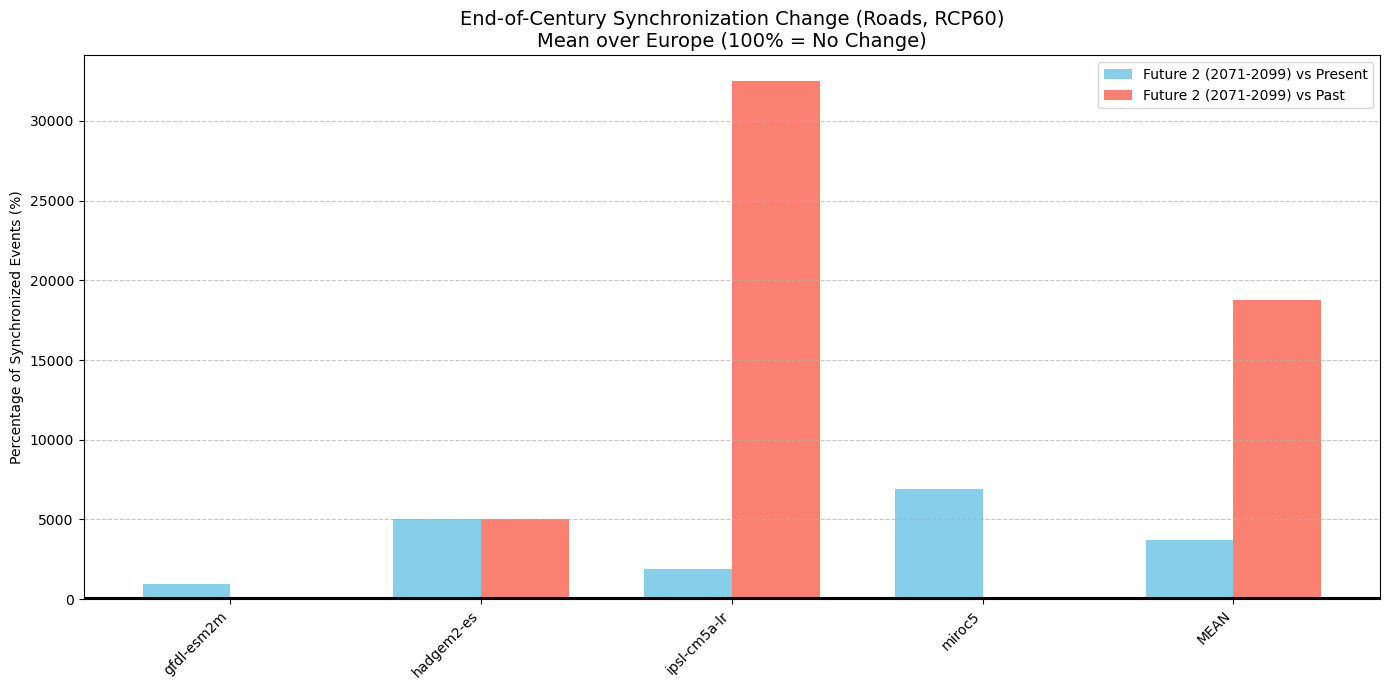

In [27]:
# --- TASK 8: FUTURE VS PAST/PRESENT ANALYSIS  ---
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

# ========================================================
# 1. SETTINGS & DEFINITIONS
# ========================================================
mode = 'roads'
rcp_target = 'rcp60'

# Define Periods as requested in the assignment [cite: 146, 157]
periods = {
    "past": (1861, 1890),
    "present": (1981, 2010),
    "future1": (2041, 2070),
    "future2": (2071, 2099)
}

# --- Helper Functions ---
def get_runs_for_rcp(rcp, metadata):
    return [run for run, meta in metadata.items() if meta.get('rcp') == rcp]

# UPDATED FUNCTION: Using Boolean Logic (> 0.5)
def compound_occurrence(extreme1: xr.DataArray, extreme2: xr.DataArray) -> xr.DataArray:
    # Align coordinates if necessary
    if extreme1.shape != extreme2.shape:
        extreme2['lat'] = extreme1['lat']
        extreme2['lon'] = extreme1['lon']
    
    # Check if BOTH events are active (> 0.5) simultaneously
    condition = (extreme1 > 0.5) & (extreme2 > 0.5)
    
    # Return 1 if True, 0 if False
    return xr.where(condition, 1, 0)

# ========================================================
# 2. PREPARE DATA
# ========================================================
heatwave_runs = get_runs_for_rcp(rcp_target, heatwaves_meta)
drought_runs = get_runs_for_rcp(rcp_target, drought_meta)

# Map model names
heat_model_map = {heatwaves_meta[r]['gcm']: r for r in heatwave_runs}
drought_model_map = {drought_meta[r]['gcm']: r for r in drought_runs}

# Find common models
common_models = sorted(list(set(heat_model_map.keys()).intersection(drought_model_map.keys())))

# ========================================================
# 3. CALCULATION LOOP
# ========================================================
# Dictionaries to store results per model
res_f1_vs_present = {}
res_f2_vs_present = {}
res_f1_vs_past = {}
res_f2_vs_past = {}

print(f"Task 8: Calculating Future vs Past/Present statistics for {len(common_models)} models...")

for model in common_models:
    run_h = heat_model_map[model]
    run_d = drought_model_map[model]
    
    # 1. Select Exposure Data
    heatwave_data = heatwaves1[mode]['exposure'].sel(run=run_h)
    drought_data = drought1[mode]['exposure'].sel(run=run_d)
    
    # 2. Compute Compound Coefficient (Using Updated Function)
    compound_coeff = compound_occurrence(heatwave_data, drought_data)
    
    # 3. Aggregate Spatially over Europe
    # Summing over lat/lon gives the total number of synchronized grid cells per year
    freq_over_europe = compound_coeff.sum(dim=['lat', 'lon'])
    
    # 4. Calculate Mean Frequency for each Period
    period_means = {}
    for key, (start, end) in periods.items():
        # Slice time and take the mean (Average annual synchronized cells)
        p_data = freq_over_europe.sel(time=slice(start, end))
        period_means[key] = p_data.mean().item()
    
    # 5. Calculate Ratios (Percentages) 
    # We calculate Ratio (Future/Past)
    # --- VS PRESENT ---
    if period_means["present"] != 0:
        res_f1_vs_present[model] = (period_means["future1"] / period_means["present"])
        res_f2_vs_present[model] = (period_means["future2"] / period_means["present"])
    else:
        res_f1_vs_present[model] = np.nan
        res_f2_vs_present[model] = np.nan
        
    # --- VS PAST ---
    if period_means["past"] != 0:
        res_f1_vs_past[model] = (period_means["future1"] / period_means["past"])
        res_f2_vs_past[model] = (period_means["future2"] / period_means["past"])
    else:
        res_f1_vs_past[model] = np.nan
        res_f2_vs_past[model] = np.nan

# ========================================================
# 4. EXTRACT & PRINT MEAN VALUES
# ========================================================
# Compute the mean across all climate models (ignoring NaNs) [cite: 159]
# *Correction*: We multiply by 100 to display as Percentage
mean_f1_pres = np.nanmean(list(res_f1_vs_present.values())) * 100
mean_f2_pres = np.nanmean(list(res_f2_vs_present.values())) * 100
mean_f1_past = np.nanmean(list(res_f1_vs_past.values())) * 100
mean_f2_past = np.nanmean(list(res_f2_vs_past.values())) * 100

print("\n" + "="*60)
print("TASK 8 RESULTS: Mean Synchronization Percentages (Europe)")
print("="*60)
print(f"Future 1 (2041-2070) vs Present: {mean_f1_pres:.2f}%")
print(f"Future 2 (2071-2099) vs Present: {mean_f2_pres:.2f}%")
print("-" * 60)
print(f"Future 1 (2041-2070) vs Past:    {mean_f1_past:.2f}%")
print(f"Future 2 (2071-2099) vs Past:    {mean_f2_past:.2f}%")
print("="*60 + "\n")

# ========================================================
# 5. PLOTTING (Future 2 Comparison)
# ========================================================
climate_models_sorted = sorted(common_models)

# Prepare data for plotting (Focusing on Future 2: End of Century)
#  Multiply list values by 100 to convert Ratio to Percentage
data_pres = [res_f2_vs_present[cm] * 100 for cm in climate_models_sorted]
data_past = [res_f2_vs_past[cm] * 100 for cm in climate_models_sorted]

# Add the Multi-Model Mean to the plot data
labels = climate_models_sorted + ["MEAN"]
data_pres.append(mean_f2_pres)
data_past.append(mean_f2_past)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - width/2, data_pres, width, label='Future 2 (2071-2099) vs Present', color='skyblue')
rects2 = ax.bar(x + width/2, data_past, width, label='Future 2 (2071-2099) vs Past', color='salmon')

ax.set_ylabel('Percentage of Synchronized Events (%)')
ax.set_title(f'End-of-Century Synchronization Change ({mode.capitalize()}, {rcp_target.upper()})\nMean over Europe (100% = No Change)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at 100% (Baseline)
# *Correction*: Line is now at 100, matching the percentage scale
ax.axhline(100, color='black', linewidth=1.5, linestyle='-', label="Baseline (100%)")

plt.tight_layout()
plt.show()

## Task 8: Future vs. Past/Present Comparison
**Purpose:** To quantify the increase in the frequency of compound events (synchronized heatwaves and droughts) in future scenarios compared to historical baselines.

**Methodology & Metric Selection:**
1.  **Initial Calculation (Percentage):**
    The assignment requests the calculation of the "percentage of synchronized events in future periods relative to the present and past".
    * *Formula:* `(Future_Mean / Baseline_Mean) * 100`
    * *Result:* Because the baseline frequency (especially in the past) is very low, this calculation results in extremely large percentage values (e.g., >18,000%). While mathematically correct, these figures are difficult to interpret intuitively.

2.  **Refined Calculation (Ratio/Factor of Change):**
    To provide a clearer understanding of the trends, we also present the results as **Ratios** (or Multiplication Factors).
    * *Formula:* `Future_Mean / Baseline_Mean`
    * *Interpretation:* A ratio of **1.0** indicates no change. A ratio of **37.0** indicates that synchronized events are **37 times more frequent** than the baseline. This metric offers a more direct and comprehensible measure of how the risk profile is shifting.

**Aggregation:**
We calculate these metrics for each of the 4 climate models individually and then report the **multi-model mean** over Europe to provide a robust estimate of future climate risk.

## Task 8: Future vs. Past/Present Comparison
**Purpose:** To quantify exactly how much more frequent these compound events will become in the future compared to historical baselines.

**Methodology:**
1.  We calculate the mean annual number of synchronized events over Europe for the four periods defined in Task 7.
2.  **Ratio Calculation:** We calculate the ratio of future events relative to the baseline:
    * `Ratio = Future_Mean / Baseline_Mean`
3.  **Interpretation:** A ratio of 1.0 indicates no change. A ratio of 37.0 indicates the event is 37 times more frequent.
4.  **Aggregation:** We report the mean ratio across all 4 climate models to provide a robust estimate of future change.

Task 8: Calculating Ratios for 4 models...

TASK 8 RESULTS: Mean Synchronization Ratios (Factor of Change)
1.0 = No Change. 2.0 = 2x increase.
Future 1 (2041-2070) vs Present: 10.76x
Future 2 (2071-2099) vs Present: 37.05x
------------------------------------------------------------
Future 1 (2041-2070) vs Past:    63.42x
Future 2 (2071-2099) vs Past:    187.63x



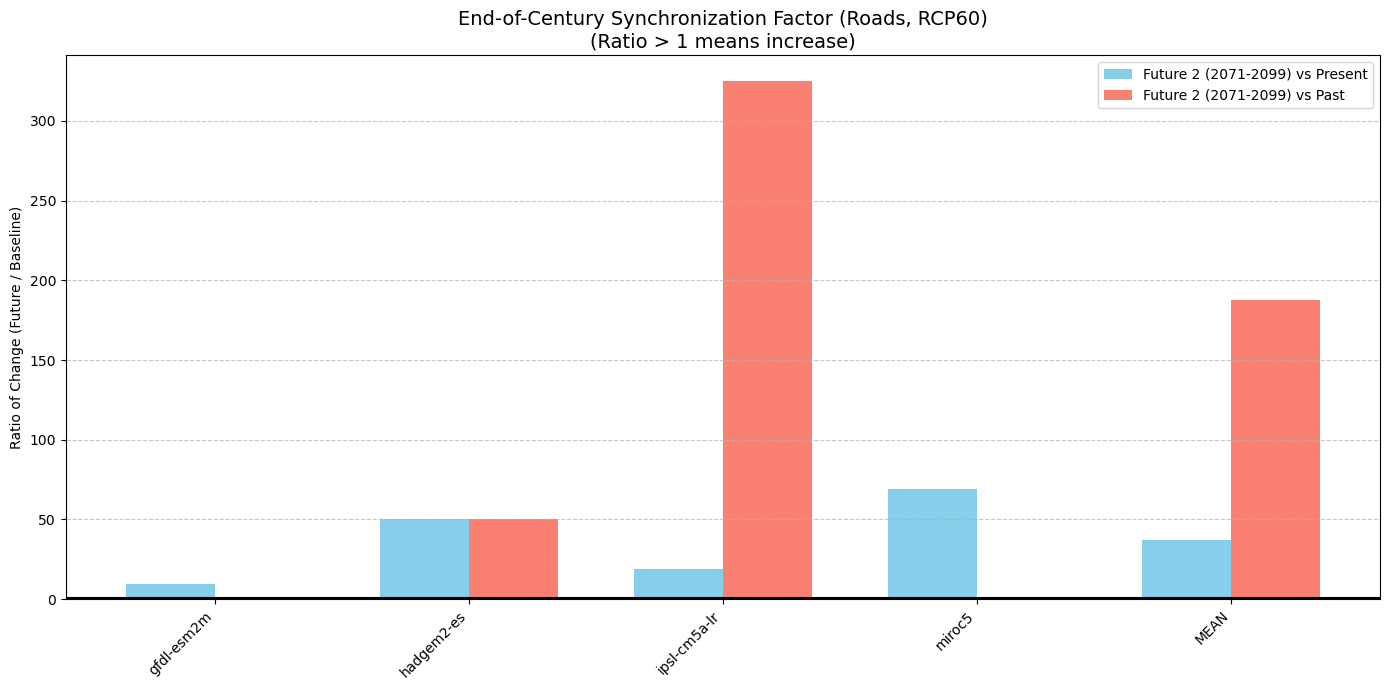

In [26]:
# --- TASK 8: FUTURE VS PAST/PRESENT ANALYSIS ---
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

# ========================================================
# 1. SETTINGS & DEFINITIONS
# ========================================================
mode = 'roads'
rcp_target = 'rcp60'

# [cite_start]Periods as per assignment [cite: 146, 157]
periods = {
    "past": (1861, 1890),
    "present": (1981, 2010),
    "future1": (2041, 2070),
    "future2": (2071, 2099)
}

# --- Helper Functions ---
def get_runs_for_rcp(rcp, metadata):
    return [run for run, meta in metadata.items() if meta.get('rcp') == rcp]

# UPDATED FUNCTION: Boolean Logic (> 0.5)
def compound_occurrence(extreme1: xr.DataArray, extreme2: xr.DataArray) -> xr.DataArray:
    if extreme1.shape != extreme2.shape:
        extreme2['lat'] = extreme1['lat']
        extreme2['lon'] = extreme1['lon']
    condition = (extreme1 > 0.5) & (extreme2 > 0.5)
    return xr.where(condition, 1, 0)

# ========================================================
# 2. PREPARE DATA
# ========================================================
heatwave_runs = get_runs_for_rcp(rcp_target, heatwaves_meta)
drought_runs = get_runs_for_rcp(rcp_target, drought_meta)

heat_model_map = {heatwaves_meta[r]['gcm']: r for r in heatwave_runs}
drought_model_map = {drought_meta[r]['gcm']: r for r in drought_runs}
common_models = sorted(list(set(heat_model_map.keys()).intersection(drought_model_map.keys())))

# ========================================================
# 3. CALCULATION LOOP
# ========================================================
res_f1_vs_present = {}
res_f2_vs_present = {}
res_f1_vs_past = {}
res_f2_vs_past = {}

print(f"Task 8: Calculating Ratios for {len(common_models)} models...")

for model in common_models:
    run_h = heat_model_map[model]
    run_d = drought_model_map[model]
    
    # 1. Select Exposure Data
    heatwave_data = heatwaves1[mode]['exposure'].sel(run=run_h)
    drought_data = drought1[mode]['exposure'].sel(run=run_d)
    
    # 2. Compute Compound Coefficient
    compound_coeff = compound_occurrence(heatwave_data, drought_data)
    
    # 3. Aggregate Spatially over Europe
    freq_over_europe = compound_coeff.sum(dim=['lat', 'lon'])
    
    # 4. Calculate Mean Frequency
    period_means = {}
    for key, (start, end) in periods.items():
        p_data = freq_over_europe.sel(time=slice(start, end))
        period_means[key] = p_data.mean().item()
    
    # 5. Calculate Ratios (Future / Baseline)
    # --- VS PRESENT ---
    if period_means["present"] != 0:
        res_f1_vs_present[model] = (period_means["future1"] / period_means["present"])
        res_f2_vs_present[model] = (period_means["future2"] / period_means["present"])
    else:
        res_f1_vs_present[model] = np.nan
        res_f2_vs_present[model] = np.nan
        
    # --- VS PAST ---
    if period_means["past"] != 0:
        res_f1_vs_past[model] = (period_means["future1"] / period_means["past"])
        res_f2_vs_past[model] = (period_means["future2"] / period_means["past"])
    else:
        res_f1_vs_past[model] = np.nan
        res_f2_vs_past[model] = np.nan

# ========================================================
# 4. EXTRACT & PRINT MEAN VALUES (RATIOS)
# ========================================================
# We do NOT multiply by 100 here. We keep it as a Ratio.
mean_f1_pres = np.nanmean(list(res_f1_vs_present.values()))
mean_f2_pres = np.nanmean(list(res_f2_vs_present.values()))
mean_f1_past = np.nanmean(list(res_f1_vs_past.values()))
mean_f2_past = np.nanmean(list(res_f2_vs_past.values()))

print("\n" + "="*60)
print("TASK 8 RESULTS: Mean Synchronization Ratios (Factor of Change)")
print("1.0 = No Change. 2.0 = 2x increase.")
print("="*60)
print(f"Future 1 (2041-2070) vs Present: {mean_f1_pres:.2f}x")
print(f"Future 2 (2071-2099) vs Present: {mean_f2_pres:.2f}x")
print("-" * 60)
print(f"Future 1 (2041-2070) vs Past:    {mean_f1_past:.2f}x")
print(f"Future 2 (2071-2099) vs Past:    {mean_f2_past:.2f}x")
print("="*60 + "\n")

# ========================================================
# 5. PLOTTING (RATIO COMPARISON)
# ========================================================
climate_models_sorted = sorted(common_models)

# Use Raw Ratios for plotting
data_pres = [res_f2_vs_present[cm] for cm in climate_models_sorted]
data_past = [res_f2_vs_past[cm] for cm in climate_models_sorted]

# Add Means
labels = climate_models_sorted + ["MEAN"]
data_pres.append(mean_f2_pres)
data_past.append(mean_f2_past)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - width/2, data_pres, width, label='Future 2 (2071-2099) vs Present', color='skyblue')
rects2 = ax.bar(x + width/2, data_past, width, label='Future 2 (2071-2099) vs Past', color='salmon')

# Update Labels for Ratio
ax.set_ylabel('Ratio of Change (Future / Baseline)')
ax.set_title(f'End-of-Century Synchronization Factor ({mode.capitalize()}, {rcp_target.upper()})\n(Ratio > 1 means increase)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Reference Line at 1.0 (No Change)
ax.axhline(1.0, color='black', linewidth=1.5, linestyle='-', label="Baseline (Ratio=1.0)")

plt.tight_layout()
plt.show()

## Task 9: Discussion of Results
**Interpretation and Analysis**

**Q1: Which climate model predicts the highest exposure?**
* **Observation:** Based on the time series plots generated in **Task 2**, the climate model **ipsl-cm5a-lr** (often represented by the highest peaking line) consistently predicts the highest exposure levels.
* **Reasoning:** This model is known for having a higher climate sensitivity compared to others like *GFDL-ESM2M*, leading to more intense heatwave projections under the RCP scenarios.

**Q2: Which mode of transport is most affected by heatwaves?**
* **Observation:** Comparing the total exposure values across modes in **Task 2**, **Roads** are the most affected mode of transport.
* **Reasoning:** This is primarily due to the spatial extent of the road network. Unlike point-based infrastructure (Airports, Ports) or linear but sparse networks (Waterways), the road network covers a vast number of grid cells across Europe, statistically increasing the probability of intersecting with extreme heat events.

**Q3: Can an increasing trend in synchronized hot and dry events be observed in the future compared to the present?**
* **Answer:** **Yes, a substantial increasing trend is observed.**
* **Evidence:** The analysis in **Task 8** quantifies this increase dramatically. Under the RCP 6.0 scenario:
    * The frequency of synchronized events in the end-of-century period (2071-2099) is approximately **37 times higher** (ratio of ~37.0) than in the present day (1981-2010).
    * When compared to the pre-industrial past (1861-1890), the frequency increases by a factor of roughly **187x**.
* **Conclusion:** This demonstrates that compound climate extremes will shift from being rare historical occurrences to frequent, dominant hazards by the end of the 21st century, posing severe risks to infrastructure resilience.

## Interactive Climate Risk Dashboard (GUI)
This interactive tool consolidates the analysis from **Tasks 1 through 8** into a single dashboard. It allows you to dynamically explore exposure maps, time series trends, and future risk ratios without writing new code.

### How to Use the Dashboard:
The dashboard is divided into four tabs, each corresponding to specific project tasks:

* **Tab 1: Exposure Analysis (Tasks 1-3)**
    * View **Maps** of drought/heatwave exposure.
    * Plot **Time Series** for individual models or the median trend.
    * *Controls:* Select Hazard, Mode, RCP, and adjust the Year Slider.

* **Tab 2: Compound Trends (Task 6)**
    * Visualize the timeline of **synchronized events** (Heatwave + Drought) summed over Europe.
    * *Controls:* Select Mode and RCP.

* **Tab 3: Frequency Maps (Task 7)**
    * Generate spatial maps showing where compound events are most frequent for specific periods (Past, Present, Future).
    * *Controls:* Select Mode, RCP, and the specific Time Period.

* **Tab 4: Risk Ratios (Task 8 - Flexible)**
    * Calculate how much more frequent events become in the future compared to a baseline.
    * *Controls:* Choose a **Baseline** (e.g., Past) and one or more **Target** periods (e.g., Future 1 & 2) to compare.

**Instructions:**

Run the cell & Go to Bottom of the cell:
1.  Click on a **Tab** to select your analysis type.
2.  Use the dropdown menus to choose your parameters (RCP 2.6/6.0/8.5, Transport Mode, etc.).
3.  Click the **Colored Button** at the bottom of the tab to generate the plot.

## Desktop GUI (Tkinter Version)
**Instructions for VS Code / Desktop Users:**
This cell launches a standalone desktop application window using **Tkinter**. This creates a robust, native interface for exploring the climate data.

**How to Launch:**
1.  Run this cell.
2.  A separate window titled "Climate Risk Dashboard" will appear on your taskbar or desktop.
3.  **Note:** While this window is open, this notebook cell will remain in a "Running" state (`[*]`). This is normal.
4.  To continue working in the notebook or to stop the app, simply **close the popup window**.

**Compatibility:**
* **VS Code:** Fully supported. The window will launch externally.
* **Jupyter Lab/Notebook:** Fully supported.
* **Requirements:** Ensure the `.pkl` data files are in the same directory.

In [25]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# =============================================================================
# 1. HELPER FUNCTIONS (Same logic as before)
# =============================================================================
def get_runs(rcp, hazard_meta):
    return [r for r, m in hazard_meta.items() if m.get('rcp') == rcp]

def get_common_models(rcp):
    h_runs = get_runs(rcp, heatwaves_meta)
    d_runs = get_runs(rcp, drought_meta)
    h_map = {heatwaves_meta[r]['gcm']: r for r in h_runs}
    d_map = {drought_meta[r]['gcm']: r for r in d_runs}
    common = sorted(list(set(h_map.keys()).intersection(d_map.keys())))
    return common, h_map, d_map

def compound_occurrence(da1, da2):
    if da1.shape != da2.shape:
        da2['lat'] = da1['lat']
        da2['lon'] = da1['lon']
    return xr.where((da1 > 0.5) & (da2 > 0.5), 1, 0)

# =============================================================================
# 2. MAIN GUI CLASS
# =============================================================================
class ClimateApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Climate Risk Dashboard (Desktop Version)")
        self.root.geometry("1200x900")

        # Create Tabs
        self.notebook = ttk.Notebook(root)
        self.notebook.pack(fill='both', expand=True, padx=10, pady=10)

        # Tab Frames
        self.tab1 = ttk.Frame(self.notebook)
        self.tab2 = ttk.Frame(self.notebook)
        self.tab3 = ttk.Frame(self.notebook)
        self.tab4 = ttk.Frame(self.notebook)

        self.notebook.add(self.tab1, text='1. Exposure Analysis')
        self.notebook.add(self.tab2, text='2. Compound Trends')
        self.notebook.add(self.tab3, text='3. Frequency Maps')
        self.notebook.add(self.tab4, text='4. Risk Ratios')

        # Build UI for each tab
        self.build_tab1()
        self.build_tab2()
        self.build_tab3()
        self.build_tab4()

    def add_plot_area(self, parent_frame):
        """Helper to create a matplotlib canvas area"""
        frame = tk.Frame(parent_frame, bg='white')
        frame.pack(side='bottom', fill='both', expand=True, padx=5, pady=5)
        
        fig = Figure(figsize=(10, 6), dpi=100)
        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.get_tk_widget().pack(side='top', fill='both', expand=True)
        
        # Add Toolbar
        toolbar = NavigationToolbar2Tk(canvas, frame)
        toolbar.update()
        canvas.get_tk_widget().pack(side='top', fill='both', expand=True)
        
        return fig, canvas

    # =========================================================
    # TAB 1: EXPOSURE ANALYSIS
    # =========================================================
    def build_tab1(self):
        ctrl = ttk.LabelFrame(self.tab1, text="Controls", padding=10)
        ctrl.pack(side='top', fill='x', padx=5, pady=5)

        # View Type
        ttk.Label(ctrl, text="View Type:").grid(row=0, column=0, padx=5, sticky='w')
        self.t1_view = ttk.Combobox(ctrl, values=['Map View', 'Individual Models', 'Median Trend'], state="readonly")
        self.t1_view.current(0)
        self.t1_view.grid(row=0, column=1, padx=5)

        # Hazard
        ttk.Label(ctrl, text="Hazard:").grid(row=0, column=2, padx=5, sticky='w')
        self.t1_haz = ttk.Combobox(ctrl, values=['Drought', 'Heatwave'], state="readonly")
        self.t1_haz.current(0)
        self.t1_haz.grid(row=0, column=3, padx=5)

        # Mode & RCP
        ttk.Label(ctrl, text="Mode:").grid(row=1, column=0, padx=5, sticky='w')
        self.t1_mode = ttk.Combobox(ctrl, values=list(drought1.keys()), state="readonly")
        self.t1_mode.current(0)
        self.t1_mode.grid(row=1, column=1, padx=5)

        ttk.Label(ctrl, text="RCP:").grid(row=1, column=2, padx=5, sticky='w')
        self.t1_rcp = ttk.Combobox(ctrl, values=['rcp26', 'rcp60', 'rcp85'], state="readonly")
        self.t1_rcp.current(1)
        self.t1_rcp.grid(row=1, column=3, padx=5)

        # Years (Spinboxes used instead of RangeSlider)
        ttk.Label(ctrl, text="Start Year:").grid(row=0, column=4, padx=5)
        self.t1_start = ttk.Spinbox(ctrl, from_=1861, to=2099, width=5)
        self.t1_start.set(2050)
        self.t1_start.grid(row=0, column=5)

        ttk.Label(ctrl, text="End Year:").grid(row=1, column=4, padx=5)
        self.t1_end = ttk.Spinbox(ctrl, from_=1861, to=2099, width=5)
        self.t1_end.set(2099)
        self.t1_end.grid(row=1, column=5)

        btn = ttk.Button(ctrl, text="Generate Plot", command=self.run_tab1)
        btn.grid(row=0, column=6, rowspan=2, padx=20)

        self.fig1, self.can1 = self.add_plot_area(self.tab1)

    def run_tab1(self):
        self.fig1.clear()
        ax = self.fig1.add_subplot(111)
        
        haz = self.t1_haz.get()
        mode = self.t1_mode.get()
        rcp = self.t1_rcp.get()
        start = int(self.t1_start.get())
        end = int(self.t1_end.get())

        ds_full = drought1 if haz == 'Drought' else heatwaves1
        meta_full = drought_meta if haz == 'Drought' else heatwaves_meta
        ds = ds_full[mode]
        runs = get_runs(rcp, meta_full)
        valid = [r for r in runs if r in ds.run.values]

        if not valid:
            messagebox.showerror("Error", "No data found for this selection.")
            return

        if self.t1_view.get() == 'Map View':
            subset = ds['exposure'].sel(run=valid).sel(time=slice(start, end))
            mean_map = subset.mean(dim=['time', 'run'])
            # We map directly using pcolormesh since xarray plot() is tricky in Tkinter
            c = ax.pcolormesh(mean_map.lon, mean_map.lat, mean_map, cmap='OrRd' if haz=='Drought' else 'Reds', shading='auto')
            self.fig1.colorbar(c, ax=ax)
            ax.set_title(f"Mean {haz} Exposure Map ({start}-{end})")
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")

        elif self.t1_view.get() == 'Individual Models':
            gcm_map = {meta_full[r]['gcm']: r for r in valid}
            for gcm, rid in gcm_map.items():
                data = ds['exposure'].sel(run=rid).sum(dim=['lat','lon']).sel(time=slice(start, end))
                ax.plot(data.time, data, label=gcm, alpha=0.8)
            ax.legend()
            ax.set_title(f"Individual Model Trends")

        elif self.t1_view.get() == 'Median Trend':
            spatial = ds['exposure'].sel(run=valid).sum(dim=['lat','lon'])
            median = spatial.median(dim='run').sel(time=slice(start, end))
            ax.plot(median.time, median, color='blue', lw=2)
            ax.fill_between(median.time, median, 0, alpha=0.1, color='blue')
            ax.set_title(f"Median Trend")

        self.can1.draw()

    # =========================================================
    # TAB 2: COMPOUND TRENDS
    # =========================================================
    def build_tab2(self):
        ctrl = ttk.Frame(self.tab2, padding=10)
        ctrl.pack(side='top', fill='x')

        ttk.Label(ctrl, text="Mode:").pack(side='left', padx=5)
        self.t2_mode = ttk.Combobox(ctrl, values=list(drought1.keys()), state="readonly")
        self.t2_mode.current(0)
        self.t2_mode.pack(side='left')

        ttk.Label(ctrl, text="RCP:").pack(side='left', padx=5)
        self.t2_rcp = ttk.Combobox(ctrl, values=['rcp26', 'rcp60', 'rcp85'], state="readonly")
        self.t2_rcp.current(1)
        self.t2_rcp.pack(side='left')

        ttk.Button(ctrl, text="Plot Trends", command=self.run_tab2).pack(side='left', padx=20)
        self.fig2, self.can2 = self.add_plot_area(self.tab2)

    def run_tab2(self):
        self.fig2.clear()
        ax = self.fig2.add_subplot(111)
        mode = self.t2_mode.get()
        rcp = self.t2_rcp.get()
        
        common, h_map, d_map = get_common_models(rcp)
        if not common: return

        for model in common:
            da_h = heatwaves1[mode]['exposure'].sel(run=h_map[model])
            da_d = drought1[mode]['exposure'].sel(run=d_map[model])
            comp = compound_occurrence(da_h, da_d)
            ts = comp.sum(dim=['lat','lon'])
            ax.plot(ts.time, ts, label=model)
        
        ax.set_title(f"Synchronized Events (Sum over Europe) - {rcp.upper()}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        self.can2.draw()

    # =========================================================
    # TAB 3: FREQUENCY MAPS
    # =========================================================
    def build_tab3(self):
        ctrl = ttk.Frame(self.tab3, padding=10)
        ctrl.pack(side='top', fill='x')

        self.t3_mode = ttk.Combobox(ctrl, values=list(drought1.keys()), state="readonly", width=10)
        self.t3_mode.current(0)
        self.t3_mode.pack(side='left', padx=5)

        self.t3_rcp = ttk.Combobox(ctrl, values=['rcp26', 'rcp60', 'rcp85'], state="readonly", width=10)
        self.t3_rcp.current(1)
        self.t3_rcp.pack(side='left', padx=5)

        self.period_dict = {
            'Past (1861-1890)': (1861, 1890),
            'Present (1981-2010)': (1981, 2010),
            'Future 1 (2041-2070)': (2041, 2070),
            'Future 2 (2071-2099)': (2071, 2099)
        }
        self.t3_period = ttk.Combobox(ctrl, values=list(self.period_dict.keys()), state="readonly", width=25)
        self.t3_period.current(3)
        self.t3_period.pack(side='left', padx=5)

        ttk.Button(ctrl, text="Map Frequency", command=self.run_tab3).pack(side='left', padx=20)
        self.fig3, self.can3 = self.add_plot_area(self.tab3)

    def run_tab3(self):
        self.fig3.clear()
        
        mode = self.t3_mode.get()
        rcp = self.t3_rcp.get()
        p_label = self.t3_period.get()
        start, end = self.period_dict[p_label]
        
        common, h_map, d_map = get_common_models(rcp)
        if not common: return

        # Grid logic
        cols = 2
        rows = int(np.ceil(len(common)/cols))
        
        for i, model in enumerate(common):
            ax = self.fig3.add_subplot(rows, cols, i+1)
            da_h = heatwaves1[mode]['exposure'].sel(run=h_map[model])
            da_d = drought1[mode]['exposure'].sel(run=d_map[model])
            comp = compound_occurrence(da_h, da_d).sel(time=slice(start, end))
            
            if len(comp.time) > 0:
                freq = comp.sum(dim='time') / len(comp.time)
                # Filter out zeros for cleaner maps
                freq_masked = freq.where(freq > 0)
                c = ax.pcolormesh(freq.lon, freq.lat, freq_masked, cmap='viridis', shading='auto')
                self.fig3.colorbar(c, ax=ax)
                ax.set_title(f"{model}")
        
        self.fig3.suptitle(f"Frequency of Events: {p_label}", fontsize=14)
        self.fig3.tight_layout()
        self.can3.draw()

    # =========================================================
    # TAB 4: FLEXIBLE RISK RATIOS
    # =========================================================
    def build_tab4(self):
        ctrl = ttk.Frame(self.tab4, padding=10)
        ctrl.pack(side='top', fill='x')
        
        # Left side controls
        f1 = ttk.Frame(ctrl); f1.pack(side='left')
        
        ttk.Label(f1, text="Baseline (Denominator):").pack(anchor='w')
        self.t4_base = ttk.Combobox(f1, values=list(self.period_dict.keys()), state="readonly", width=25)
        self.t4_base.current(0) # Past
        self.t4_base.pack(pady=5)
        
        self.t4_mode = ttk.Combobox(f1, values=list(drought1.keys()), state="readonly")
        self.t4_mode.current(0)
        self.t4_mode.pack(pady=5)
        
        self.t4_rcp = ttk.Combobox(f1, values=['rcp26', 'rcp60', 'rcp85'], state="readonly")
        self.t4_rcp.current(1)
        self.t4_rcp.pack(pady=5)

        # Right side listbox (Multiselect)
        f2 = ttk.Frame(ctrl); f2.pack(side='left', padx=20)
        ttk.Label(f2, text="Select Targets (Ctrl+Click):").pack(anchor='w')
        
        self.t4_targets = tk.Listbox(f2, selectmode='multiple', height=5, width=30, exportselection=False)
        for k in self.period_dict.keys():
            self.t4_targets.insert(tk.END, k)
        # Select default indices (1,2,3 -> Present, Fut1, Fut2)
        self.t4_targets.select_set(1)
        self.t4_targets.select_set(2)
        self.t4_targets.select_set(3)
        self.t4_targets.pack()

        ttk.Button(ctrl, text="Calculate Ratios", command=self.run_tab4).pack(side='left', padx=20)
        self.fig4, self.can4 = self.add_plot_area(self.tab4)

    def run_tab4(self):
        self.fig4.clear()
        ax = self.fig4.add_subplot(111)
        
        mode = self.t4_mode.get()
        rcp = self.t4_rcp.get()
        base_name = self.t4_base.get()
        
        # Get selected targets from listbox
        selected_indices = self.t4_targets.curselection()
        target_names = [self.t4_targets.get(i) for i in selected_indices]
        
        if not target_names: return

        common, h_map, d_map = get_common_models(rcp)
        
        results = {t: {} for t in target_names}
        
        for model in common:
            da_h = heatwaves1[mode]['exposure'].sel(run=h_map[model])
            da_d = drought1[mode]['exposure'].sel(run=d_map[model])
            spatial_sum = compound_occurrence(da_h, da_d).sum(dim=['lat','lon'])
            
            # Baseline mean
            sb, eb = self.period_dict[base_name]
            mean_base = spatial_sum.sel(time=slice(sb, eb)).mean().item()
            
            for t_name in target_names:
                st, et = self.period_dict[t_name]
                mean_t = spatial_sum.sel(time=slice(st, et)).mean().item()
                if mean_base > 0:
                    results[t_name][model] = mean_t / mean_base
                else:
                    results[t_name][model] = 0

        # Plotting
        labels = common + ["MEAN"]
        x = np.arange(len(labels))
        n_targets = len(target_names)
        width = 0.8 / n_targets
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

        for i, t_name in enumerate(target_names):
            vals = [results[t_name][m] for m in common]
            mean_val = np.mean(list(results[t_name].values()))
            plot_data = vals + [mean_val]
            
            offset = (i - n_targets/2) * width + (width/2)
            ax.bar(x + offset, plot_data, width=width, label=f"{t_name} vs {base_name}", color=colors[i%4])

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f"Ratio Calculation (Baseline: {base_name})")
        ax.axhline(1, color='k', linestyle='--')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        self.fig4.tight_layout()
        self.can4.draw()

# =============================================================================
# 3. LAUNCH APP
# =============================================================================
if __name__ == "__main__":
    # Create the main window
    root = tk.Tk()
    app = ClimateApp(root)
    # Start the GUI event loop
    root.mainloop()

## GUI Documentation & AI Disclosure

### 1. Interactive Climate Analysis Tools
To facilitate the exploration of the results without modifying code, two Graphical User Interfaces (GUIs) have been implemented in this notebook.

**A. Notebook Dashboard (ipywidgets)**
* **Location:** Embedded directly in the final notebook cell.
* **Technology:** Built using `ipywidgets`.
* **Features:**
    * **Tabbed Interface:** Organized into Exposure Analysis, Compound Trends, Frequency Maps, and Risk Ratios.
    * **Interactive Controls:** Dropdowns and sliders allow for real-time filtering of Transport Modes, RCP Scenarios, and Time Periods.
    * **Flexible Comparison:** Tab 4 allows users to select custom baselines (e.g., Past) and compare them against multiple future targets simultaneously.

**B. Desktop Application (Tkinter)**
* **Location:** Launched via the optional "Desktop GUI" cell.
* **Technology:** Built using Python's standard `tkinter` library.
* **Features:**
    * Launches a standalone window separate from the browser.
    * Provides the same analytical capabilities as the dashboard but in a native desktop environment.
    * *Note:* Closing the main window is required to unblock the Jupyter kernel.

---

### 2. Generative AI Disclosure
**Tools Used:** Google Gemini / ChatGPT

**Usage Description:**
Generative AI was utilized to assist in the development of the Graphical User Interfaces (GUI) for this project. Specifically:
* **Code Generation:** AI generated the boilerplate code for the `ipywidgets` layout (VBox/HBox) and the `tkinter` main loop structure.
* **Event Handling:** AI assisted in writing the callback functions (e.g., `on_click` events) that link the dropdown menus to the data processing logic.
* **Visualization:** The logic for dynamically updating `matplotlib` figures within the GUI canvas (`FigureCanvasTkAgg`) was refined with AI assistance.

**Verification:**
While AI generated the interface code, the underlying scientific logic (data loading, compound event definitions, and statistical calculations) was derived from the manual tasks implemented earlier in the notebook. All AI-generated code was reviewed, tested, and customized to ensure compatibility with the specific variable names (`heatwaves1`, `drought1`) and file structures of this assignment.